In [ ]:
import importlib.util as importlib_util
import os
from pathlib import Path
import subprocess
import sys

In [ ]:
notebook_required_packages = [
    ("marimo>=0.22.4", "marimo"),
    ("litellm", "litellm"),
    ("pydantic", "pydantic"),
    ("pandas", "pandas"),
    ("openpyxl", "openpyxl"),
    ("python-dotenv", "dotenv"),
    ("mlflow", "mlflow"),
    ("tqdm", "tqdm"),
    ("tenacity", "tenacity"),
    ("seaborn>=0.13.2", "seaborn"),
    ("matplotlib", "matplotlib"),
]
notebook_missing_packages = [
    notebook_package_spec
    for notebook_package_spec, notebook_module_name in notebook_required_packages
    if importlib_util.find_spec(notebook_module_name) is None
]
if notebook_missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", *notebook_missing_packages]
    )
    print(f"Installed: {', '.join(notebook_missing_packages)}")
else:
    print("Dependencies already installed.")

Dependencies already installed.


In [ ]:
import marimo as mo

# Assignment 1

In [ ]:
bundle_candidates = []
bundle_env_root = os.getenv("ASSIGNMENT_BUNDLE_ROOT", "").strip()
if bundle_env_root:
    bundle_candidates.append(Path(bundle_env_root).expanduser())

if "__file__" in globals():
    bundle_candidates.append(Path(__file__).resolve().parent)

bundle_cwd = Path.cwd().resolve()
bundle_candidates.extend(
    [
        bundle_cwd,
        bundle_cwd / "colab_bundle",
        bundle_cwd.parent / "colab_bundle",
        bundle_cwd / "w2-ai-product" / "colab_bundle",
        Path("/content/colab_bundle"),
        Path("/content/w2-ai-product/colab_bundle"),
    ]
)

BUNDLE_ROOT = None
bundle_checked_paths = []
bundle_seen_paths = set()
for bundle_candidate_path in bundle_candidates:
    bundle_candidate_key = str(bundle_candidate_path)
    if bundle_candidate_key in bundle_seen_paths:
        continue
    bundle_seen_paths.add(bundle_candidate_key)
    bundle_checked_paths.append(bundle_candidate_path)
    if (
        (bundle_candidate_path / "assignment_colab.py").exists()
        and (bundle_candidate_path / "data" / "products.csv").exists()
    ):
        BUNDLE_ROOT = bundle_candidate_path.resolve()
        break

if BUNDLE_ROOT is None:
    raise FileNotFoundError(
        "Could not find the notebook project root. Checked: "
        + ", ".join(str(bundle_path) for bundle_path in bundle_checked_paths)
    )

os.chdir(BUNDLE_ROOT)

print(f"Project root: {BUNDLE_ROOT}")

Project root: /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product


In [ ]:
import litellm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import mlflow
import pandas as pd
import seaborn as sns
from tqdm import tqdm

## Notebook Setup

This notebook is self-contained:
- prompt text is embedded in notebook cells,
- shared helpers for scoring and judging live in this file,
- packaged artifacts are reused when present,
- live model calls only run when a required artifact is missing.

In [ ]:
import json
from collections.abc import Callable, Iterable
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from enum import Enum
from typing import Any, TypeVar, cast

from dotenv import load_dotenv
from mlflow.entities import ViewType
from mlflow.exceptions import MlflowException
from pydantic import BaseModel, ValidationError
from tenacity import retry, retry_if_exception_type, stop_after_attempt, wait_exponential

DATA_DIR = BUNDLE_ROOT / "data"
OUTPUTS_DIR = BUNDLE_ROOT / "outputs"
OUTPUTS_REPORTS_DIR = OUTPUTS_DIR / "reports"
PRODUCTS_CSV_PATH = DATA_DIR / "products.csv"
ASSIGNMENT_XLSX_PATH = OUTPUTS_DIR / "assignment_01.xlsx"
TASK_04_EXPERIMENTS_XLSX_PATH = OUTPUTS_DIR / "task_04_experiments.xlsx"
TASK_05_JUDGE_SANITY_CSV_PATH = OUTPUTS_DIR / "task_05_judge_sanity.csv"
TASK_06_JUDGED_EXPERIMENTS_CSV_PATH = OUTPUTS_DIR / "task_06_judged_experiments.csv"
MLFLOW_DB_PATH = OUTPUTS_DIR / "experiments.db"

PROMPT_GENERATION_V1 = """You are a professional e-commerce copywriter. Your task is to write a persuasive product description based solely on the information provided.

## Rules
1. Length: write exactly 50-90 words. Count carefully before submitting.
2. Tone: friendly, credible sales voice. Highlight benefits, not just specs.
3. Grounding: use ONLY information from the product data provided. Do not invent features, add claims, or embellish beyond what is explicitly stated.
4. Fluency: write in natural, flowing English sentences. Avoid bullet points, lists, or fragmented phrases.
5. Grammar: use correct spelling and punctuation throughout.

## Output format
Return only the product description - no headings, no labels, no commentary.
"""

PROMPT_GENERATION_V3 = """You are a professional e-commerce copywriter. Your task is to write a persuasive product description based solely on the information provided.

## Rules
1. Length: write exactly 50-90 words. Count carefully before submitting.
2. Grounding: use ONLY information from the product data provided. Do not invent features, benefits, performance claims, convenience claims, use cases, battery behavior, charging behavior, or durability claims beyond what is explicitly stated.
3. Tone: friendly, credible sales voice. Write like polished e-commerce copy, not like a product spec sheet rewritten as a paragraph.
4. Fluency: write in natural, flowing English sentences. Avoid bullet points, lists, fragmented phrases, and one-sentence-per-feature writing.
5. Grammar: use correct spelling and punctuation throughout.

## Writing style
- Lead with the product's main customer-facing appeal or benefit.
- Mention only the 2-3 most relevant details from the input.
- Integrate details naturally into sentences instead of enumerating every attribute.
- If a detail feels awkward, low-value, or hard to use naturally, omit it rather than forcing it into the copy.
- Avoid repetitive marketing filler and stiff warranty-driven endings.

## Bad pattern to avoid
Do NOT mechanically convert each feature into a sentence. Do NOT force suspicious or awkward fields into the copy.

### Bad example (do not imitate)
Product: Stanley Quencher H2.0 40 oz
Attributes: features: vacuum insulated, flow-state lid, cup-holder friendly; battery: long-lasting
Material: recycled stainless steel
Warranty: lifetime warranty

Bad description:
Stay refreshed on-the-go with the Stanley Quencher H2.0 40 oz. This durable, recycled stainless steel bottle keeps drinks hot or cold for hours, thanks to its vacuum insulated design. The flow-state lid makes sipping easy, and the cup-holder friendly design ensures it fits securely in your car's holder. Plus, the long-lasting battery powers a feature that's yet to be revealed. With a lifetime warranty, you can trust this bottle to keep up with your active lifestyle.

Why it is bad:
- invents a battery-related claim for a tumbler
- forces every field into the copy even when it creates nonsense
- sounds gimmicky and unnatural

## Output format
Return only the product description - no headings, no labels, no commentary.
"""

PROMPT_GENERATION_V4 = """You are a professional e-commerce copywriter. Your task is to write a persuasive product description based solely on the information provided.

## Rules
1. Length: write exactly 50-90 words. Count carefully before submitting.
2. Grounding: use ONLY information from the product data provided. Do not invent features, benefits, performance claims, convenience claims, use cases, battery behavior, charging behavior, or durability claims beyond what is explicitly stated.
3. Tone: friendly, credible sales voice. Write like polished e-commerce copy, not like a product spec sheet rewritten as a paragraph.
4. Fluency: write in natural, flowing English sentences. Avoid bullet points, lists, fragmented phrases, and one-sentence-per-feature writing.
5. Grammar: use correct spelling and punctuation throughout.

## Writing style
- Lead with the product's main customer-facing appeal or benefit.
- Mention only the 2-3 most relevant details from the input.
- Integrate details naturally into sentences instead of enumerating every attribute.
- If a detail feels awkward, low-value, or hard to use naturally, omit it rather than forcing it into the copy.
- Avoid repetitive marketing filler and stiff warranty-driven endings.

## Hidden structure
Internally organize the description like this:
1. Open with the main appeal or use-case.
2. Support it with 2-3 grounded details from the input.
3. Close with a brief reassuring detail such as material, fit, or warranty.
Do not output labels, bullets, or numbered structure.

## Bad pattern to avoid
Do NOT mechanically convert each feature into a sentence. Do NOT force suspicious or awkward fields into the copy.

### Bad example (do not imitate)
Product: Stanley Quencher H2.0 40 oz
Attributes: features: vacuum insulated, flow-state lid, cup-holder friendly; battery: long-lasting
Material: recycled stainless steel
Warranty: lifetime warranty

Bad description:
Stay refreshed on-the-go with the Stanley Quencher H2.0 40 oz. This durable, recycled stainless steel bottle keeps drinks hot or cold for hours, thanks to its vacuum insulated design. The flow-state lid makes sipping easy, and the cup-holder friendly design ensures it fits securely in your car's holder. Plus, the long-lasting battery powers a feature that's yet to be revealed. With a lifetime warranty, you can trust this bottle to keep up with your active lifestyle.

Why it is bad:
- invents a battery-related claim for a tumbler
- forces every field into the copy even when it creates nonsense
- sounds gimmicky and unnatural

## Output format
Return only the product description - no headings, no labels, no commentary.
"""

PROMPT_SELECTION_V1 = """You are selecting the better e-commerce product description candidate.

## Priority order
1. Grounding: reject any candidate that invents unsupported claims or awkwardly forces suspicious fields into the copy.
2. Fluency: prefer the candidate that sounds more natural and less like a feature list.
3. Tone: prefer the candidate that sounds polished, credible, and customer-facing without hype.
4. Concision: if both are otherwise similar, prefer the tighter description.

## Decision rule
Return only `A` or `B`.
- Choose the candidate that is safer and more grounded.
- If both are equally grounded, choose the more natural and persuasive one.
- Do not explain your answer.
"""

PROMPT_JUDGE_ALL_TEMPLATE = """You are an expert product description evaluator. Your task is to rate a generated product description against an evaluation rubric.

You will receive:
1. The ORIGINAL PRODUCT DATA (name, attributes, material, warranty)
2. The GENERATED DESCRIPTION to evaluate

For each criterion below, you must:
- First write your reasoning (explanation)
- Then give a verdict: "good", "ok", or "bad"

## Evaluation Rubric

{rubric_block}

## Important
- Evaluate only what is written; do not give credit for information that was provided but omitted from the description.
- For grounding, be strict: if a specific claim cannot be traced to the original product data, flag it.
- Your explanation must come BEFORE your verdict.
"""

PROMPT_JUDGE_SINGLE_TEMPLATE = """You are an expert product description evaluator. Your task is to rate a generated product description on ONE specific criterion.

You will receive:
1. The ORIGINAL PRODUCT DATA (name, attributes, material, warranty)
2. The GENERATED DESCRIPTION to evaluate
3. The criterion to evaluate and its rubric

## Criterion to Evaluate
**{criterion_name}** - {criterion_description}

### Rubric
- good: {good}
- ok:   {ok}
- bad:  {bad}

## Instructions
- Focus exclusively on this criterion. Do not consider other aspects of the description.
- First write your reasoning (explanation), then give your verdict: "good", "ok", or "bad".
- Your explanation must come BEFORE your verdict.
{extra_instructions}
"""

DEFAULT_FINAL_PROVIDER = "nebius"
DEFAULT_GENERATION_MODEL_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"
IMPROVEMENT_GENERATION_MODEL_ID = "Qwen/Qwen3-30B-A3B-Instruct-2507"
DEFAULT_JUDGE_MODEL_ID = "Qwen/Qwen3-30B-A3B-Instruct-2507"
DEFAULT_JUDGE_MODEL_PRESET = "qwen"
JUDGE_MODEL_PRESETS = {
    "qwen": "Qwen/Qwen3-30B-A3B-Instruct-2507",
    "gemma": "google/gemma-2-9b-it-fast",
}
DEFAULT_JUDGE_MAX_CONCURRENCY = 6
MAX_JUDGE_MAX_CONCURRENCY = 8

MODEL_PRICE_FALLBACKS = {
    "nebius/meta-llama/Meta-Llama-3.1-8B-Instruct": {
        "input_cost_per_token": 0.02 / 1_000_000,
        "output_cost_per_token": 0.06 / 1_000_000,
        "price_source": "Nebius Token Factory pricing page checked on 2026-04-10",
    },
    "nebius/Qwen/Qwen3-30B-A3B-Instruct-2507": {
        "input_cost_per_token": 0.10 / 1_000_000,
        "output_cost_per_token": 0.30 / 1_000_000,
        "price_source": "Nebius Token Factory pricing page checked on 2026-04-10",
    },
    "nebius/Qwen/Qwen3-30B-A3B": {
        "input_cost_per_token": 0.10 / 1_000_000,
        "output_cost_per_token": 0.30 / 1_000_000,
        "price_source": "Nebius Token Factory pricing page checked on 2026-04-10",
    },
    "nebius/google/gemma-2-9b-it": {
        "input_cost_per_token": 0.03 / 1_000_000,
        "output_cost_per_token": 0.09 / 1_000_000,
        "price_source": "Nebius Token Factory pricing page checked on 2026-04-10",
    },
}

runtime_state = {
    "dotenv_loaded": False,
    "litellm_autolog_enabled": False,
}

@dataclass(frozen=True)
class ModelConfig:
    provider: str
    model_id: str

    @property
    def model(self) -> str:
        return f"{self.provider}/{self.model_id}"

class Rating(str, Enum):
    GOOD = "good"
    OK = "ok"
    BAD = "bad"

@dataclass
class CriterionDefinition:
    name: str
    description: str
    good: str
    ok: str
    bad: str
    judged: bool = True

RUBRIC: list[CriterionDefinition] = [
    CriterionDefinition(
        name="Fluency",
        description="Natural, easy-to-read sentences",
        good="Natural, easy-to-read flow; no awkward phrasing or unnatural constructions",
        ok="Mostly natural but 1-2 awkward phrases or choppy transitions",
        bad="Stilted, robotic, or hard to follow; multiple unnatural constructions",
    ),
    CriterionDefinition(
        name="Grammar",
        description="Correct spelling and punctuation",
        good="Zero spelling or punctuation errors",
        ok="1-2 minor errors that don't impede understanding",
        bad="3+ errors, or any error that changes meaning or is immediately visible",
    ),
    CriterionDefinition(
        name="Tone",
        description="Matches friendly, credible sales voice",
        good="Friendly, credible sales voice; persuasive without being pushy or hyperbolic",
        ok="Mostly appropriate but occasionally too formal, too casual, or generic",
        bad="Inappropriate tone: overly aggressive, robotic, or clearly mismatched to product",
    ),
    CriterionDefinition(
        name="Length",
        description="50-90 words",
        good="50-90 words (inclusive)",
        ok="40-49 words or 91-110 words",
        bad="Fewer than 40 words or more than 110 words",
    ),
    CriterionDefinition(
        name="Grounding",
        description="Sticks to information provided (no hallucination)",
        good="Every claim is traceable to the provided product name, attributes, material, or warranty; no invented features",
        ok="Minor embellishment that is reasonable for the product category but not explicitly in the data (for example, 'premium feel')",
        bad="Fabricated specs, invented features, or claims that contradict the provided data",
    ),
    CriterionDefinition(
        name="Latency",
        description="Avg. time per API call (ms)",
        good="< 2 000 ms",
        ok="2 000-5 000 ms",
        bad="> 5 000 ms",
        judged=False,
    ),
    CriterionDefinition(
        name="Cost",
        description="Avg. price per API call (USD)",
        good="< $0.000 5",
        ok="$0.000 5-$0.002",
        bad="> $0.002",
        judged=False,
    ),
]
JUDGED_CRITERIA = [criterion for criterion in RUBRIC if criterion.judged]
CRITERION_COLS = [criterion.name.lower() for criterion in RUBRIC]
JUDGED_COLS = [criterion.name.lower() for criterion in JUDGED_CRITERIA]
GO_NO_GO = {"grounding", "length"}
PASS_MIN_GOOD = 4
PASS_MAX_BAD = 0

class CriterionJudgment(BaseModel):
    explanation: str
    verdict: Rating

class JudgeOutput(BaseModel):
    fluency: CriterionJudgment
    grammar: CriterionJudgment
    tone: CriterionJudgment
    length: CriterionJudgment
    grounding: CriterionJudgment

    def to_ratings(self) -> dict[str, str]:
        return {
            "fluency": self.fluency.verdict.value,
            "grammar": self.grammar.verdict.value,
            "tone": self.tone.verdict.value,
            "length": self.length.verdict.value,
            "grounding": self.grounding.verdict.value,
        }

def get_generation_config() -> ModelConfig:
    return ModelConfig(
        provider=os.getenv("GENERATION_PROVIDER", DEFAULT_FINAL_PROVIDER),
        model_id=os.getenv("GENERATION_MODEL", DEFAULT_GENERATION_MODEL_ID),
    )

def build_model_config(provider: str, model_id: str) -> ModelConfig:
    return ModelConfig(provider=provider, model_id=model_id)

def get_judge_config() -> ModelConfig:
    explicit_model_id = os.getenv("JUDGE_MODEL", "").strip()
    if explicit_model_id:
        model_id = explicit_model_id
    else:
        preset = os.getenv(
            "JUDGE_MODEL_PRESET", DEFAULT_JUDGE_MODEL_PRESET
        ).strip().lower()
        model_id = JUDGE_MODEL_PRESETS.get(preset, DEFAULT_JUDGE_MODEL_ID)
    return ModelConfig(
        provider=os.getenv("JUDGE_PROVIDER", DEFAULT_FINAL_PROVIDER),
        model_id=model_id,
    )

def get_judge_model_choice() -> str:
    explicit_model_id = os.getenv("JUDGE_MODEL", "").strip()
    if explicit_model_id:
        return f"custom ({explicit_model_id})"
    preset = os.getenv(
        "JUDGE_MODEL_PRESET", DEFAULT_JUDGE_MODEL_PRESET
    ).strip().lower()
    if preset in JUDGE_MODEL_PRESETS:
        return preset
    return f"unknown preset ({preset}) -> default qwen"

def get_judge_max_concurrency() -> int:
    raw_value = os.getenv("JUDGE_MAX_CONCURRENCY", str(DEFAULT_JUDGE_MAX_CONCURRENCY))
    try:
        value = int(raw_value)
    except ValueError:
        value = DEFAULT_JUDGE_MAX_CONCURRENCY
    return max(1, min(value, MAX_JUDGE_MAX_CONCURRENCY))

def get_judge_timeout_seconds() -> int:
    raw_value = os.getenv("JUDGE_TIMEOUT_SECONDS", "90")
    try:
        value = int(raw_value)
    except ValueError:
        value = 90
    return max(15, min(value, 300))

def get_judge_sanity_max_concurrency() -> int:
    raw_value = os.getenv("JUDGE_SANITY_MAX_CONCURRENCY", "2")
    try:
        value = int(raw_value)
    except ValueError:
        value = 2
    return max(1, min(value, 5))

def get_judge_all_max_tokens() -> int:
    raw_value = os.getenv("JUDGE_ALL_MAX_TOKENS", "600")
    try:
        value = int(raw_value)
    except ValueError:
        value = 600
    return max(200, min(value, 1024))

def get_judge_single_max_tokens() -> int:
    raw_value = os.getenv("JUDGE_SINGLE_MAX_TOKENS", "220")
    try:
        value = int(raw_value)
    except ValueError:
        value = 220
    return max(120, min(value, 512))

def get_force_rerun() -> bool:
    return os.getenv("FORCE_RERUN", "0").strip().lower() in {"1", "true", "yes", "on"}

def rate_latency_ms(latency_ms: float) -> str:
    if latency_ms < 2000:
        return Rating.GOOD.value
    if latency_ms < 5000:
        return Rating.OK.value
    return Rating.BAD.value

def rate_cost_usd(cost_usd: float) -> str:
    if cost_usd < 0.0005:
        return Rating.GOOD.value
    if cost_usd < 0.002:
        return Rating.OK.value
    return Rating.BAD.value

def compute_final_score(ratings: dict[str, str]) -> str:
    normalized = {
        criterion: str(ratings.get(criterion, "")).strip().lower()
        for criterion in CRITERION_COLS
    }
    if any(value not in ("good", "ok", "bad") for value in normalized.values()):
        return ""
    if any(normalized[criterion] == "bad" for criterion in GO_NO_GO):
        return "fail"
    goods = sum(1 for value in normalized.values() if value == "good")
    bads = sum(1 for value in normalized.values() if value == "bad")
    if goods >= PASS_MIN_GOOD and bads <= PASS_MAX_BAD:
        return "pass"
    return "fail"

def render_rubric_for_prompt(
    judged_only: bool = True,
    extra_notes: dict[str, str] | None = None,
) -> str:
    criteria = JUDGED_CRITERIA if judged_only else RUBRIC
    note_by_name = {key.lower(): value for key, value in (extra_notes or {}).items()}
    lines = []
    for criterion in criteria:
        lines.append(f"### {criterion.name} - {criterion.description}")
        lines.append(f"- good: {criterion.good}")
        lines.append(f"- ok:   {criterion.ok}")
        lines.append(f"- bad:  {criterion.bad}")
        note = note_by_name.get(criterion.name.lower())
        if note:
            lines.append(f"Note: {note}")
        lines.append("")
    return "\n".join(lines).strip()

def _has_required_columns(df: pd.DataFrame, required_columns: Iterable[str]) -> bool:
    return all(column in df.columns for column in tuple(required_columns))

def load_csv_artifact(
    path: Path,
    *,
    required_columns: Iterable[str] = (),
) -> pd.DataFrame | None:
    if not path.exists():
        return None
    try:
        df = pd.read_csv(path)
    except Exception:
        return None
    if not _has_required_columns(df, required_columns):
        return None
    return df

def load_excel_artifact(
    path: Path,
    *,
    required_columns: Iterable[str] = (),
    sheet_name: str | int = 0,
) -> pd.DataFrame | None:
    if not path.exists():
        return None
    try:
        df = pd.read_excel(path, sheet_name=sheet_name)
    except Exception:
        return None
    if not isinstance(df, pd.DataFrame):
        return None
    if not _has_required_columns(df, required_columns):
        return None
    return df

def format_product(product: dict) -> str:
    """Render one product row into the prompt/judge text format."""
    return (
        f"Product: {product.get('product_name', '')}\n"
        f"Attributes: {product.get('Product_attribute_list', '')}\n"
        f"Material: {product.get('material', '')}\n"
        f"Warranty: {product.get('warranty', '')}"
    )

def format_judge_input(product: dict, description: str) -> str:
    return (
        f"## Original Product Data\n{format_product(product)}\n\n"
        f"## Generated Description\n{description}"
    )

def _get_fallback_token_prices(model: str | None) -> tuple[float, float] | None:
    if not model:
        return None
    fallback = MODEL_PRICE_FALLBACKS.get(model)
    if fallback is None:
        return None
    return (
        float(fallback["input_cost_per_token"]),
        float(fallback["output_cost_per_token"]),
    )

def extract_cost(
    response: Any,
    input_tokens: int,
    output_tokens: int,
    *,
    model: str | None = None,
) -> float:
    """Use LiteLLM's model pricing when available, else a narrow local fallback."""
    try:
        cost = litellm.completion_cost(completion_response=response)
        if cost and cost > 0:
            return cost
    except Exception:
        pass
    fallback_prices = _get_fallback_token_prices(
        model or getattr(response, "model", None)
    )
    if fallback_prices is None:
        raise ValueError(
            f"No fallback pricing configured for model: {model or getattr(response, 'model', None)}"
        )
    input_price, output_price = fallback_prices
    return (input_tokens * input_price) + (output_tokens * output_price)

T = TypeVar("T")
R = TypeVar("R")

def run_sync_batch(
    fn: Callable[[T], R],
    items: list[T],
    max_concurrency: int = 5,
    desc: str | None = None,
) -> list[R]:
    """Execute a synchronous callable over many items with bounded concurrency."""
    results = cast(list[R | None], [None for _ in items])
    with ThreadPoolExecutor(max_workers=max_concurrency) as executor:
        futures = {
            executor.submit(fn, item): index
            for index, item in enumerate(items)
        }
        iterator = as_completed(futures)
        if desc:
            iterator = tqdm(iterator, total=len(futures), desc=desc)
        for future in iterator:
            results[futures[future]] = future.result()
    return [cast(R, result) for result in results]

def load_project_env() -> Path:
    env_path = BUNDLE_ROOT / ".env"
    if not runtime_state["dotenv_loaded"]:
        load_dotenv(env_path)
        runtime_state["dotenv_loaded"] = True
    return env_path

def _restore_deleted_experiment(experiment_name: str) -> bool:
    client = mlflow.MlflowClient()
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment and experiment.lifecycle_stage == "deleted":
        client.restore_experiment(experiment.experiment_id)
        return True
    for experiment in client.search_experiments(view_type=ViewType.DELETED_ONLY):
        if experiment.name == experiment_name:
            client.restore_experiment(experiment.experiment_id)
            return True
    return False

def setup_mlflow(experiment_name: str) -> Path:
    OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUTS_REPORTS_DIR.mkdir(parents=True, exist_ok=True)
    mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH}")
    _restore_deleted_experiment(experiment_name)
    try:
        mlflow.set_experiment(experiment_name)
    except MlflowException as exc:
        if "deleted experiment" not in str(exc).lower() or not _restore_deleted_experiment(
            experiment_name
        ):
            raise
        mlflow.set_experiment(experiment_name)
    if not runtime_state["litellm_autolog_enabled"]:
        mlflow.litellm.autolog()
        runtime_state["litellm_autolog_enabled"] = True
    return MLFLOW_DB_PATH

def build_all_criteria_prompt(prompt_template: str) -> str:
    rubric_block = render_rubric_for_prompt(
        judged_only=True,
        extra_notes={
            "length": "count the words in the description carefully before deciding.",
            "grounding": (
                "for grounding, compare the description against the ORIGINAL PRODUCT DATA "
                "carefully. Only accept claims that appear in the data."
            ),
        },
    )
    return prompt_template.format(rubric_block=rubric_block)

def create_all_at_once_judge(
    *,
    model: str,
    prompt: str,
    format_judge_input: Callable[[dict, str], str],
    max_tokens: int,
    timeout_seconds: int,
) -> Callable[[dict, str], JudgeOutput]:
    """Create a structured-output judge that scores all judged criteria at once."""
    @retry(
        stop=stop_after_attempt(3),
        wait=wait_exponential(multiplier=1, min=1, max=8),
        retry=retry_if_exception_type(
            (
                litellm.APIError,
                litellm.APIConnectionError,
                litellm.InternalServerError,
                litellm.RateLimitError,
                litellm.ServiceUnavailableError,
                litellm.Timeout,
                ValidationError,
                json.JSONDecodeError,
                KeyError,
            )
        ),
    )
    def run_judge(product: dict, description: str) -> JudgeOutput:
        response = litellm.completion(
            model=model,
            messages=[
                {"role": "system", "content": prompt},
                {"role": "user", "content": format_judge_input(product, description)},
            ],
            response_format={
                "type": "json_schema",
                "json_schema": {
                    "name": "JudgeOutput",
                    "schema": JudgeOutput.model_json_schema(),
                    "strict": True,
                },
            },
            temperature=0.0,
            max_tokens=max_tokens,
            timeout=timeout_seconds,
        )
        return JudgeOutput.model_validate_json(response.choices[0].message.content)

    return run_judge

def create_single_judges(
    *,
    model: str,
    prompt_template: str,
    judged_criteria: list[CriterionDefinition],
    format_judge_input: Callable[[dict, str], str],
    max_tokens: int,
    timeout_seconds: int,
) -> dict[str, Callable[[dict, str], CriterionJudgment]]:
    """Create one structured-output judge callable per criterion."""
    def _make_single_judge(criterion: CriterionDefinition) -> Callable[[dict, str], CriterionJudgment]:
        extra = ""
        if criterion.name == "Grounding":
            extra = (
                "Note: compare the description against the ORIGINAL PRODUCT DATA carefully. "
                "Only accept claims traceable to the provided fields."
            )
        elif criterion.name == "Length":
            extra = "Note: count the words in the description carefully before deciding."

        prompt = prompt_template.format(
            criterion_name=criterion.name,
            criterion_description=criterion.description,
            good=criterion.good,
            ok=criterion.ok,
            bad=criterion.bad,
            extra_instructions=extra,
        )

        @retry(
            stop=stop_after_attempt(3),
            wait=wait_exponential(multiplier=1, min=1, max=8),
            retry=retry_if_exception_type(
                (
                    litellm.APIError,
                    litellm.APIConnectionError,
                    litellm.InternalServerError,
                    litellm.RateLimitError,
                    litellm.ServiceUnavailableError,
                    litellm.Timeout,
                    ValidationError,
                    json.JSONDecodeError,
                    KeyError,
                )
            ),
        )
        def _judge_single(product: dict, description: str) -> CriterionJudgment:
            response = litellm.completion(
                model=model,
                messages=[
                    {"role": "system", "content": prompt},
                    {"role": "user", "content": format_judge_input(product, description)},
                ],
                response_format={
                    "type": "json_schema",
                    "json_schema": {
                        "name": "CriterionJudgment",
                        "schema": CriterionJudgment.model_json_schema(),
                        "strict": True,
                    },
                },
                temperature=0.0,
                max_tokens=max_tokens,
                timeout=timeout_seconds,
            )
            return CriterionJudgment.model_validate_json(response.choices[0].message.content)

        return _judge_single

    return {
        criterion.name.lower(): _make_single_judge(criterion)
        for criterion in judged_criteria
    }

TASK4_EXPERIMENTS_SHEET = "experiments"
TASK4_SUMMARY_SHEET = "summary"
TASK4_EXPERIMENT_KEY_COL = "experiment_key"
TASK4_EXPERIMENT_LABEL_COL = "experiment_label"
TASK4_BASELINE_KEY = "baseline"
TASK4_BASELINE_LABEL = "Baseline"
TASK4_ARTIFACTS_DIR = OUTPUTS_REPORTS_DIR / "task_04_experiments"
TASK4_EXPERIMENT_SPECS: dict[str, dict[str, str]] = {
    "exp1": {
        "label": "Exp 1",
        "generator": "Llama-3.1-8B",
        "model_id": "nebius/meta-llama/Meta-Llama-3.1-8B-Instruct",
        "prompt_or_policy": "generation_v3_voice",
        "run_name": "exp1_llama8b_prompt_v3_voice",
    },
    "exp2": {
        "label": "Exp 2",
        "generator": "Qwen3-30B",
        "model_id": "nebius/Qwen/Qwen3-30B-A3B",
        "prompt_or_policy": "generation_v3_voice",
        "run_name": "exp2_qwen30b_prompt_v3_voice",
    },
    "exp3": {
        "label": "Exp 3",
        "generator": "Llama-3.1-8B",
        "model_id": "nebius/meta-llama/Meta-Llama-3.1-8B-Instruct",
        "prompt_or_policy": "generation_v4_scaffold",
        "run_name": "exp3_llama8b_prompt_v4_scaffold",
    },
    "exp4": {
        "label": "Exp 4",
        "generator": "Llama-3.1-8B + selector",
        "model_id": "nebius/meta-llama/Meta-Llama-3.1-8B-Instruct",
        "prompt_or_policy": "generation_v4_scaffold + generation_selector_v1",
        "run_name": "exp4_llama8b_prompt_v4_best_of_2_sequential",
    },
}
TASK4_EXPERIMENT_ORDER = [TASK4_BASELINE_KEY, *TASK4_EXPERIMENT_SPECS.keys()]
TASK4_MANUAL_COLS = ["comparison_sample", *JUDGED_COLS, "final_score"]

def _product_key(value: object) -> str:
    return " ".join(str(value).split())

def _normalize_manual_columns(df: pd.DataFrame) -> pd.DataFrame:
    normalized = df.copy()
    for column in TASK4_MANUAL_COLS:
        if column not in normalized.columns:
            normalized[column] = ""
    return normalized

def _annotate_experiment_metadata(
    df: pd.DataFrame,
    *,
    experiment_key: str,
    label: str,
    generator: str,
    prompt_or_policy: str,
    run_id: str,
    table_path: str,
    is_baseline: bool,
) -> pd.DataFrame:
    annotated = df.copy()
    annotated[TASK4_EXPERIMENT_KEY_COL] = experiment_key
    annotated[TASK4_EXPERIMENT_LABEL_COL] = label
    annotated["generator"] = generator
    annotated["prompt_or_policy"] = prompt_or_policy
    annotated["run_id"] = run_id
    annotated["table_path"] = table_path
    annotated["is_baseline"] = is_baseline
    return annotated

def _read_existing_experiments_df(workbook_path: Path) -> pd.DataFrame | None:
    """Load the current Task 4 workbook format if it already exists."""
    if not workbook_path.exists():
        return None
    existing_sheets = pd.read_excel(workbook_path, sheet_name=None)
    if TASK4_EXPERIMENTS_SHEET not in existing_sheets:
        return None
    existing = existing_sheets[TASK4_EXPERIMENTS_SHEET].copy()
    if TASK4_EXPERIMENT_KEY_COL not in existing.columns or "product_name" not in existing.columns:
        return None
    return _normalize_manual_columns(existing)

def _preserve_manual_scores(
    df_new: pd.DataFrame,
    existing_experiments_df: pd.DataFrame | None,
) -> pd.DataFrame:
    if existing_experiments_df is None:
        return _normalize_manual_columns(df_new)
    # Baseline labels should come from the current Task 2 workbook, not an older Task 4 export.
    baseline_new = df_new[
        df_new[TASK4_EXPERIMENT_KEY_COL] == TASK4_BASELINE_KEY
    ].copy()
    experiments_new = df_new[
        df_new[TASK4_EXPERIMENT_KEY_COL] != TASK4_BASELINE_KEY
    ].copy()
    existing_experiments_df = existing_experiments_df[
        existing_experiments_df[TASK4_EXPERIMENT_KEY_COL] != TASK4_BASELINE_KEY
    ].copy()
    if existing_experiments_df.empty:
        return _normalize_manual_columns(
            pd.concat([baseline_new, experiments_new], ignore_index=True, sort=False)
        )
    keep_cols = [
        column
        for column in [TASK4_EXPERIMENT_KEY_COL, "product_name", *JUDGED_COLS]
        if column in existing_experiments_df.columns
    ]
    if len(keep_cols) < 2:
        return _normalize_manual_columns(
            pd.concat([baseline_new, experiments_new], ignore_index=True, sort=False)
        )
    existing_scores = existing_experiments_df[keep_cols].copy()
    existing_scores["__product_key"] = existing_scores["product_name"].map(_product_key)
    existing_scores = existing_scores.drop_duplicates(
        subset=[TASK4_EXPERIMENT_KEY_COL, "__product_key"],
        keep="last",
    )
    merged = experiments_new.copy()
    merged["__product_key"] = merged["product_name"].map(_product_key)
    merged = merged.drop(
        columns=[column for column in [*JUDGED_COLS, "final_score"] if column in merged.columns]
    ).merge(
        existing_scores.drop(columns=["product_name"]),
        on=[TASK4_EXPERIMENT_KEY_COL, "__product_key"],
        how="left",
    )
    merged = merged.drop(columns=["__product_key"])
    return _normalize_manual_columns(
        pd.concat([baseline_new, merged], ignore_index=True, sort=False)
    )

def _resolve_comparison_names(
    baseline_df: pd.DataFrame,
    existing_experiments_df: pd.DataFrame | None,
) -> set[str]:
    if "comparison_sample" in baseline_df.columns:
        comparison_mask = baseline_df["comparison_sample"].fillna("").astype(str).str.strip().eq("yes")
        comparison_names = {
            _product_key(name)
            for name in baseline_df.loc[comparison_mask, "product_name"].tolist()
        }
        if comparison_names:
            return comparison_names
    scored_mask = baseline_df["fluency"].fillna("").astype(str).str.strip() != ""
    comparison_names = {
        _product_key(name)
        for name in baseline_df.loc[scored_mask, "product_name"].tolist()
    }
    if comparison_names:
        return comparison_names
    if existing_experiments_df is not None:
        existing_baseline = existing_experiments_df[
            existing_experiments_df[TASK4_EXPERIMENT_KEY_COL] == TASK4_BASELINE_KEY
        ].copy()
        if not existing_baseline.empty:
            comparison_mask = existing_baseline["comparison_sample"].fillna("").astype(str).str.strip().eq("yes")
            comparison_names = {
                _product_key(name)
                for name in existing_baseline.loc[comparison_mask, "product_name"].tolist()
            }
            if comparison_names:
                return comparison_names
    return {_product_key(name) for name in baseline_df.head(15)["product_name"].tolist()}

def _mark_comparison_sample(df_experiments: pd.DataFrame, comparison_names: set[str]) -> pd.DataFrame:
    marked = df_experiments.copy()
    marked["comparison_sample"] = marked["product_name"].map(
        lambda value: "yes" if _product_key(value) in comparison_names else ""
    )
    return marked

def _rate_programmatic_value(value: object, rater: Callable[[float], str]) -> str:
    if pd.isna(value):
        return ""
    return rater(float(str(value)))

def apply_programmatic_scores(df: pd.DataFrame) -> pd.DataFrame:
    """Apply only the programmatic criteria and recompute final_score when possible."""
    scored = df.copy()
    scored["latency"] = scored["latency_ms"].map(
        lambda value: _rate_programmatic_value(value, rate_latency_ms)
    )
    scored["cost"] = scored["cost_usd"].map(
        lambda value: _rate_programmatic_value(value, rate_cost_usd)
    )
    scored["final_score"] = scored.apply(
            lambda row: compute_final_score({column: row.get(column, "") for column in CRITERION_COLS}),
        axis=1,
    )
    return scored

def _sort_experiments(df_experiments: pd.DataFrame) -> pd.DataFrame:
    ordered = df_experiments.copy()
    ordered["__experiment_order"] = ordered[TASK4_EXPERIMENT_KEY_COL].map(
        {key: index for index, key in enumerate(TASK4_EXPERIMENT_ORDER)}
    )
    ordered["__product_key"] = ordered["product_name"].map(_product_key)
    ordered = ordered.sort_values(["__experiment_order", "__product_key"], kind="stable")
    return ordered.drop(columns=["__experiment_order", "__product_key"]).reset_index(drop=True)

def _pass_rate_summary(df_experiment: pd.DataFrame) -> dict[str, object]:
    comparison_mask = df_experiment["comparison_sample"].fillna("").astype(str).str.strip().eq("yes")
    scored_mask = df_experiment["fluency"].fillna("").astype(str).str.strip() != ""
    scored = df_experiment[comparison_mask & scored_mask].copy()
    first_row = df_experiment.iloc[0]
    pass_count = int((scored["final_score"] == "pass").sum()) if len(scored) else 0
    fail_count = int((scored["final_score"] == "fail").sum()) if len(scored) else 0
    pass_rate = (pass_count / len(scored)) if len(scored) else None
    return {
        "experiment_key": first_row[TASK4_EXPERIMENT_KEY_COL],
        "experiment": first_row[TASK4_EXPERIMENT_LABEL_COL],
        "generator": first_row["generator"],
        "prompt_or_policy": first_row["prompt_or_policy"],
        "rows": len(df_experiment),
        "comparison_rows": int(comparison_mask.sum()),
        "n_scored": len(scored),
        "pass_count": pass_count,
        "fail_count": fail_count,
        "pass_rate": pass_rate,
        "mean_latency_ms": round(df_experiment["latency_ms"].mean(), 1),
        "total_cost_usd": round(df_experiment["cost_usd"].sum(), 8),
        "run_id": first_row["run_id"],
        "table_path": first_row["table_path"],
    }

def build_task4_experiments_table(
    *,
    baseline_df: pd.DataFrame,
    experiment_outputs: dict[str, dict[str, object]],
    products: pd.DataFrame,
    existing_experiments_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Merge Task 4 experiment outputs into one scoring workbook table."""
    baseline_rows = _annotate_experiment_metadata(
        baseline_df.copy(),
        experiment_key=TASK4_BASELINE_KEY,
        label=TASK4_BASELINE_LABEL,
        generator="Llama-3.1-8B",
        prompt_or_policy="generation_v1",
        run_id="",
        table_path=str(ASSIGNMENT_XLSX_PATH),
        is_baseline=True,
    )
    experiment_frames = [baseline_rows]
    for experiment_key, meta in experiment_outputs.items():
        df_result = meta["df"]
        if not isinstance(df_result, pd.DataFrame):
            raise TypeError(f"Task 4 experiment '{experiment_key}' is missing a DataFrame payload.")
        experiment_sheet = products.merge(df_result, on="product_name", how="left")
        experiment_frames.append(
            _annotate_experiment_metadata(
                experiment_sheet,
                experiment_key=experiment_key,
                label=str(meta["label"]),
                generator=str(meta["generator"]),
                prompt_or_policy=str(meta["prompt_or_policy"]),
                run_id=str(meta.get("run_id", "")),
                table_path=str(meta["table_path"]),
                is_baseline=False,
            )
        )
    experiments_df = pd.concat(experiment_frames, ignore_index=True, sort=False)
    experiments_df = _preserve_manual_scores(experiments_df, existing_experiments_df)
    comparison_names = _resolve_comparison_names(baseline_df, existing_experiments_df)
    experiments_df = _mark_comparison_sample(experiments_df, comparison_names)
    experiments_df = apply_programmatic_scores(experiments_df)
    return _sort_experiments(experiments_df)

def build_task4_summary(experiments_df: pd.DataFrame) -> pd.DataFrame:
    summary_rows: list[dict[str, object]] = []
    for experiment_key in TASK4_EXPERIMENT_ORDER:
        df_experiment = experiments_df[
            experiments_df[TASK4_EXPERIMENT_KEY_COL] == experiment_key
        ].copy()
        if df_experiment.empty:
            continue
        summary_rows.append(_pass_rate_summary(df_experiment))
    return pd.DataFrame(summary_rows)

def build_task4_analysis_tables(experiments_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    manual_cols = list(JUDGED_COLS)
    rating_points = {"good": 1.0, "ok": 0.5, "bad": 0.0}
    criterion_rows: list[dict[str, object]] = []
    failure_rows: list[dict[str, object]] = []
    for experiment_key in TASK4_EXPERIMENT_ORDER:
        df_experiment = experiments_df[
            experiments_df[TASK4_EXPERIMENT_KEY_COL] == experiment_key
        ].copy()
        if df_experiment.empty:
            continue
        comparison_mask = df_experiment["comparison_sample"].fillna("").astype(str).str.strip().eq("yes")
        scored_mask = df_experiment["fluency"].fillna("").astype(str).str.strip() != ""
        sample_df = df_experiment[comparison_mask & scored_mask].copy()
        experiment_label = str(df_experiment[TASK4_EXPERIMENT_LABEL_COL].iloc[0])
        criterion_row: dict[str, object] = {"Experiment": experiment_label}
        for criterion in CRITERION_COLS:
            criterion_row[criterion.title()] = sample_df[criterion].map(rating_points).mean()
        criterion_row["Pass rate"] = sample_df["final_score"].eq("pass").mean()
        criterion_rows.append(criterion_row)
        failure_rows.append(
            {
                "Experiment": experiment_label,
                "Scored sample": f"{len(sample_df)}/{int(comparison_mask.sum())}",
                "Latency bad": int(sample_df["latency"].eq("bad").sum()),
                "Grounding bad": int(sample_df["grounding"].eq("bad").sum()),
                "Any content bad": int(sample_df[manual_cols].eq("bad").any(axis=1).sum()),
                "Final fails": int(sample_df["final_score"].eq("fail").sum()),
            }
        )
    return pd.DataFrame(criterion_rows), pd.DataFrame(failure_rows)

def load_task4_experiment_outputs(
    artifacts_dir: Path = TASK4_ARTIFACTS_DIR,
) -> dict[str, dict[str, object]]:
    experiment_outputs: dict[str, dict[str, object]] = {}
    for key, spec in TASK4_EXPERIMENT_SPECS.items():
        run_names = [spec["run_name"]]
        if key == "exp4":
            run_names.append("exp4_llama8b_prompt_v4_best_of_2")
        table_path = next(
            (
                artifacts_dir / f"{run_name}.csv"
                for run_name in run_names
                if (artifacts_dir / f"{run_name}.csv").exists()
            ),
            None,
        )
        if table_path is None:
            raise FileNotFoundError(
                "Missing packaged Task 4 output for "
                f"{key}: tried {', '.join(f'{run_name}.csv' for run_name in run_names)}. "
                "Re-run that experiment first."
            )
        experiment_outputs[key] = {
            **spec,
            "df": pd.read_csv(table_path),
            "run_id": "",
            "table_path": str(table_path),
        }
    return experiment_outputs

def export_task4_workbook(
    *,
    baseline_df: pd.DataFrame,
    experiment_outputs: dict[str, dict[str, object]],
    products: pd.DataFrame,
    workbook_path: Path = TASK_04_EXPERIMENTS_XLSX_PATH,
) -> tuple[Path, pd.DataFrame, pd.DataFrame]:
    """Write the consolidated Task 4 workbook and summary sheet."""
    existing_experiments_df = _read_existing_experiments_df(workbook_path)
    experiments_df = build_task4_experiments_table(
        baseline_df=baseline_df,
        experiment_outputs=experiment_outputs,
        products=products,
        existing_experiments_df=existing_experiments_df,
    )
    summary_df = build_task4_summary(experiments_df)
    workbook_path.parent.mkdir(parents=True, exist_ok=True)
    with pd.ExcelWriter(workbook_path) as writer:
        experiments_df.to_excel(writer, sheet_name=TASK4_EXPERIMENTS_SHEET, index=False)
        summary_df.to_excel(writer, sheet_name=TASK4_SUMMARY_SHEET, index=False)
    return workbook_path, experiments_df, summary_df

In [ ]:
NOTEBOOK_ENV_PATH = load_project_env()
NOTEBOOK_FORCE_RERUN = get_force_rerun()
NOTEBOOK_EXP4_PARALLEL_CANDIDATES = os.getenv(
    "EXP4_PARALLEL_CANDIDATES", "0"
).strip().lower() in {"1", "true", "yes", "on"}
NOTEBOOK_GENERATION_CONFIG = get_generation_config()
NOTEBOOK_JUDGE_CONFIG = get_judge_config()
NOTEBOOK_JUDGE_MODEL_CHOICE = get_judge_model_choice()
NOTEBOOK_JUDGE_ALL_MAX_TOKENS = get_judge_all_max_tokens()
NOTEBOOK_JUDGE_MAX_CONCURRENCY = get_judge_max_concurrency()
NOTEBOOK_JUDGE_SANITY_MAX_CONCURRENCY = get_judge_sanity_max_concurrency()
NOTEBOOK_JUDGE_SINGLE_MAX_TOKENS = get_judge_single_max_tokens()
NOTEBOOK_JUDGE_TIMEOUT_SECONDS = get_judge_timeout_seconds()

TASK2_PROMPT_TEXT = PROMPT_GENERATION_V1
TASK5_PROMPT_TEXT = build_all_criteria_prompt(PROMPT_JUDGE_ALL_TEMPLATE)
TASK6_SINGLE_PROMPT_TEMPLATE = PROMPT_JUDGE_SINGLE_TEMPLATE

NOTEBOOK_HAS_ENV_FILE = NOTEBOOK_ENV_PATH.exists()
NOTEBOOK_HAS_NEBIUS_KEY = bool(os.getenv("NEBIUS_API_KEY", "").strip())
NOTEBOOK_TASK4_REPORTS_DIR = TASK4_ARTIFACTS_DIR

In [ ]:
mo.md(
    f"""
    ## Notebook status

    - Project root detected locally
    - Shared logic is embedded in this notebook
    - `.env` path: `{NOTEBOOK_ENV_PATH.name}`
    - `.env` present: `{NOTEBOOK_HAS_ENV_FILE}`
    - `NEBIUS_API_KEY` present: `{NOTEBOOK_HAS_NEBIUS_KEY}`
    - Force rerun: `{NOTEBOOK_FORCE_RERUN}`
    - Exp 4 parallel candidates: `{NOTEBOOK_EXP4_PARALLEL_CANDIDATES}`
    - Generation model: `{NOTEBOOK_GENERATION_CONFIG.model}`
    - Judge model choice: `{NOTEBOOK_JUDGE_MODEL_CHOICE}`
    - Judge model: `{NOTEBOOK_JUDGE_CONFIG.model}`
    - Judge all-at-once max tokens: `{NOTEBOOK_JUDGE_ALL_MAX_TOKENS}`
    - Judge max concurrency: `{NOTEBOOK_JUDGE_MAX_CONCURRENCY}`
    - Judge sanity max concurrency: `{NOTEBOOK_JUDGE_SANITY_MAX_CONCURRENCY}`
    - Judge single max tokens: `{NOTEBOOK_JUDGE_SINGLE_MAX_TOKENS}`
    - Judge timeout seconds: `{NOTEBOOK_JUDGE_TIMEOUT_SECONDS}`

    ## Packaged files

    - `{PRODUCTS_CSV_PATH.name}`
    - `{ASSIGNMENT_XLSX_PATH.name}`
    - `{TASK_04_EXPERIMENTS_XLSX_PATH.name}`
    - `{TASK_05_JUDGE_SANITY_CSV_PATH.name}`
    - `{TASK_06_JUDGED_EXPERIMENTS_CSV_PATH.name}`
    """
)

## Notebook status

- Project root detected locally
- Shared logic is embedded in this notebook
- `.env` path: `.env`
- `.env` present: `True`
- `NEBIUS_API_KEY` present: `True`
- Force rerun: `False`
- Exp 4 parallel candidates: `False`
- Generation model: `nebius/meta-llama/Meta-Llama-3.1-8B-Instruct`
- Judge model choice: `qwen`
- Judge model: `nebius/Qwen/Qwen3-30B-A3B-Instruct-2507`
- Judge all-at-once max tokens: `600`
- Judge max concurrency: `6`
- Judge sanity max concurrency: `2`
- Judge single max tokens: `220`
- Judge timeout seconds: `90`

## Packaged files

- `products.csv`
- `assignment_01.xlsx`
- `task_04_experiments.xlsx`
- `task_05_judge_sanity.csv`
- `task_06_judged_experiments.csv`

# Task 1 — Evaluation Rubric

In [ ]:
task1_evaluated_by = {
    "latency": "Programmatic",
    "cost": "Programmatic",
}
task1_rubric_df = pd.DataFrame(
    [
        {
            "Criterion": task1_criterion.name,
            "Description": task1_criterion.description,
            "Good": task1_criterion.good,
            "OK": task1_criterion.ok,
            "Bad": task1_criterion.bad,
            "Evaluated by": task1_evaluated_by.get(
                task1_criterion.name.lower(),
                "Human + Judge" if task1_criterion.judged else "Programmatic",
            ),
        }
        for task1_criterion in RUBRIC
    ]
)
mo.ui.table(task1_rubric_df, label="Rubric summary")

,_marimo_row_id,Criterion,Description,Good,OK,Bad,Evaluated by
0,0,Fluency,"Natural, easy-to-read sentences","Natural, easy-to-read flow; no awkward phrasin...",Mostly natural but 1-2 awkward phrases or chop...,"Stilted, robotic, or hard to follow; multiple ...",Human + Judge
1,1,Grammar,Correct spelling and punctuation,Zero spelling or punctuation errors,1-2 minor errors that don't impede understanding,"3+ errors, or any error that changes meaning o...",Human + Judge
2,2,Tone,"Matches friendly, credible sales voice","Friendly, credible sales voice; persuasive wit...",Mostly appropriate but occasionally too formal...,"Inappropriate tone: overly aggressive, robotic...",Human + Judge
3,3,Length,50-90 words,50-90 words (inclusive),40-49 words or 91-110 words,Fewer than 40 words or more than 110 words,Human + Judge
4,4,Grounding,Sticks to information provided (no hallucination),Every claim is traceable to the provided produ...,Minor embellishment that is reasonable for the...,"Fabricated specs, invented features, or claims...",Human + Judge
5,5,Latency,Avg. time per API call (ms),< 2 000 ms,2 000-5 000 ms,> 5 000 ms,Programmatic
6,6,Cost,Avg. price per API call (USD),< $0.000 5,$0.000 5-$0.002,> $0.002,Programmatic


In [ ]:
task1_go_no_go = ", ".join(sorted(GO_NO_GO))
mo.md("""
## Pass / fail rules
""")
mo.md(
    f"""
    - Cumulative pass bar: at least `{PASS_MIN_GOOD}` `good` ratings and at most `{PASS_MAX_BAD}` `bad` ratings.
    - Automatic fail criteria: `{task1_go_no_go}`.
    """
)
mo.md("## Rubric as used by the judge")
mo.md(render_rubric_for_prompt(judged_only=True))

### Fluency - Natural, easy-to-read sentences
- good: Natural, easy-to-read flow; no awkward phrasing or unnatural constructions
- ok:   Mostly natural but 1-2 awkward phrases or choppy transitions
- bad:  Stilted, robotic, or hard to follow; multiple unnatural constructions

### Grammar - Correct spelling and punctuation
- good: Zero spelling or punctuation errors
- ok:   1-2 minor errors that don't impede understanding
- bad:  3+ errors, or any error that changes meaning or is immediately visible

### Tone - Matches friendly, credible sales voice
- good: Friendly, credible sales voice; persuasive without being pushy or hyperbolic
- ok:   Mostly appropriate but occasionally too formal, too casual, or generic
- bad:  Inappropriate tone: overly aggressive, robotic, or clearly mismatched to product

### Length - 50-90 words
- good: 50-90 words (inclusive)
- ok:   40-49 words or 91-110 words
- bad:  Fewer than 40 words or more than 110 words

### Grounding - Sticks to information provided (no hallucination)
- good: Every claim is traceable to the provided product name, attributes, material, or warranty; no invented features
- ok:   Minor embellishment that is reasonable for the product category but not explicitly in the data (for example, 'premium feel')
- bad:  Fabricated specs, invented features, or claims that contradict the provided data

# Task 2 — Generate Product Descriptions

Flow:
- load the generation prompt,
- check whether `assignment_01.xlsx` already exists,
- if yes, analyze it,
- if not, call the model and create it.

In [ ]:
mo.md("## Task 2 prompt")
mo.md(TASK2_PROMPT_TEXT)

You are a professional e-commerce copywriter. Your task is to write a persuasive product description based solely on the information provided.

## Rules
1. Length: write exactly 50-90 words. Count carefully before submitting.
2. Tone: friendly, credible sales voice. Highlight benefits, not just specs.
3. Grounding: use ONLY information from the product data provided. Do not invent features, add claims, or embellish beyond what is explicitly stated.
4. Fluency: write in natural, flowing English sentences. Avoid bullet points, lists, or fragmented phrases.
5. Grammar: use correct spelling and punctuation throughout.

## Output format
Return only the product description - no headings, no labels, no commentary.

Cost note:
- use LiteLLM pricing when the exact Nebius model is mapped locally,
- otherwise use the official Nebius Token Factory fallback rates embedded in this notebook.
- current embedded rates checked on 2026-04-10:
  `Meta-Llama-3.1-8B-Instruct` = $0.02 / 1M input, $0.06 / 1M output
  `Qwen3-30B-A3B-Instruct-2507` = $0.10 / 1M input, $0.30 / 1M output
  `Gemma-2-9b-it` = $0.03 / 1M input, $0.09 / 1M output

In [ ]:
task2_required_columns = [
    "product_name",
    "generated_description",
    "latency_ms",
    "input_tokens",
    "output_tokens",
    "cost_usd",
    "fluency",
    "grammar",
    "tone",
    "length",
    "grounding",
    "latency",
    "cost",
    "final_score",
]

task2_existing_df = None
if not NOTEBOOK_FORCE_RERUN:
    task2_existing_df = load_excel_artifact(
        ASSIGNMENT_XLSX_PATH,
        required_columns=task2_required_columns,
    )

if task2_existing_df is not None:
    task2_assignment_df = task2_existing_df.copy()
    TASK2_SOURCE = "Loaded packaged artifact: outputs/assignment_01.xlsx"
else:
    if not NOTEBOOK_HAS_NEBIUS_KEY:
        raise RuntimeError(
            "Task 2 artifact is missing and NEBIUS_API_KEY is not set."
        )

    import time

    task2_products_df = pd.read_csv(PRODUCTS_CSV_PATH)
    task2_generation_rows = []
    setup_mlflow("product_descriptions")
    with mlflow.start_run(run_name="generation_v1_llama8b"):
        mlflow.log_params(
            {
                "model": NOTEBOOK_GENERATION_CONFIG.model_id,
                "provider": NOTEBOOK_GENERATION_CONFIG.provider,
                "prompt_version": "v1",
                "temperature": 0.3,
                "max_tokens": 200,
            }
        )
        for _, task2_product_row in tqdm(
            task2_products_df.iterrows(),
            total=len(task2_products_df),
            desc="Generating baseline",
        ):
            task2_started_at = time.perf_counter_ns()
            task2_response = litellm.completion(
                model=NOTEBOOK_GENERATION_CONFIG.model,
                messages=[
                    {"role": "system", "content": TASK2_PROMPT_TEXT},
                    {
                        "role": "user",
                        "content": format_product(task2_product_row.to_dict()),
                    },
                ],
                temperature=0.3,
                max_tokens=200,
            )
            task2_latency_ms = (time.perf_counter_ns() - task2_started_at) / 1e6
            task2_input_tokens = task2_response.usage.prompt_tokens
            task2_output_tokens = task2_response.usage.completion_tokens
            task2_cost_usd = extract_cost(
                task2_response,
                task2_input_tokens,
                task2_output_tokens,
                model=NOTEBOOK_GENERATION_CONFIG.model,
            )
            task2_generation_rows.append(
                {
                    "generated_description": task2_response.choices[0].message.content.strip(),
                    "latency_ms": round(task2_latency_ms, 1),
                    "input_tokens": task2_input_tokens,
                    "output_tokens": task2_output_tokens,
                    "cost_usd": round(task2_cost_usd, 8),
                }
            )
        task2_metrics_df = pd.DataFrame(task2_generation_rows)
        mlflow.log_metrics(
            {
                "mean_latency_ms": task2_metrics_df["latency_ms"].mean(),
                "total_cost_usd": task2_metrics_df["cost_usd"].sum(),
                "mean_input_tokens": task2_metrics_df["input_tokens"].mean(),
                "mean_output_tokens": task2_metrics_df["output_tokens"].mean(),
            }
        )
    task2_assignment_df = pd.concat(
        [
            task2_products_df.reset_index(drop=True),
            pd.DataFrame(task2_generation_rows).reset_index(drop=True),
        ],
        axis=1,
    )
    for task2_blank_column in [
        "fluency",
        "grammar",
        "tone",
        "length",
        "grounding",
        "latency",
        "cost",
        "final_score",
    ]:
        if task2_blank_column not in task2_assignment_df.columns:
            task2_assignment_df[task2_blank_column] = ""
    TASK2_SOURCE = "Live generation ran and wrote: outputs/assignment_01.xlsx"

task2_assignment_df = apply_programmatic_scores(task2_assignment_df)
ASSIGNMENT_XLSX_PATH.parent.mkdir(parents=True, exist_ok=True)
task2_assignment_df.to_excel(ASSIGNMENT_XLSX_PATH, index=False)

In [ ]:
mo.md(
    f"""
    ## Task 2 status

    - Source: {TASK2_SOURCE}
    - Provider/model: `{NOTEBOOK_GENERATION_CONFIG.model}`
    - If `assignment_01.xlsx` is missing, this section will call the generation model.
    """
)

## Task 2 status

- Source: Loaded packaged artifact: outputs/assignment_01.xlsx
- Provider/model: `nebius/meta-llama/Meta-Llama-3.1-8B-Instruct`
- If `assignment_01.xlsx` is missing, this section will call the generation model.

In [ ]:
mo.ui.table(
    task2_assignment_df[
        [
            "product_name",
            "generated_description",
            "latency_ms",
            "input_tokens",
            "output_tokens",
            "cost_usd",
        ]
    ].head(10),
    label="First 10 generated descriptions",
)

,_marimo_row_id,product_name,generated_description,latency_ms,input_tokens,output_tokens,cost_usd
0,0,Apple iPhone 15 Pro,Experience the future of smartphones with the ...,5156.2,214,97,0.000010
1,1,Samsung Galaxy S24 Ultra,Capture life's moments with unparalleled clari...,1899.5,217,96,0.000010
2,2,Google Pixel 8 Pro,Capture life's moments with the Google Pixel 8...,2399.7,215,94,0.000010
3,3,Sony WH‑1000XM5 Headphones,Immerse yourself in pure sound with the Sony W...,4320.1,214,98,0.000010
4,4,Bose QuietComfort Ultra Earbuds,Immerse yourself in pure sound with the Bose Q...,4414.3,208,99,0.000010
5,5,Amazon Echo Dot (5th Gen),"Meet the Amazon Echo Dot (5th Gen), a compact ...",2365.4,204,98,0.000010
6,6,Dell XPS 13 9310 Laptop,Experience the perfect blend of style and perf...,4510.3,222,105,0.000011
7,7,Apple MacBook Air 13″ (M3),Get ready to experience seamless performance w...,3090.0,213,105,0.000011
8,8,Microsoft Surface Pro 10,Experience the ultimate in portability and pow...,2975.6,206,88,0.000009
9,9,Garmin Forerunner 255,Take your runs to the next level with the Garm...,3904.9,216,111,0.000011


# Task 3 — Manual (Human) Evaluation

Flow:
- use the Task 2 workbook,
- compute programmatic latency/cost labels,
- read back any manual ratings already present,
- summarize the baseline.

In [ ]:
task3_assignment_df = pd.read_excel(ASSIGNMENT_XLSX_PATH)
task3_scored_df = task3_assignment_df[
    task3_assignment_df["fluency"].fillna("").astype(str).str.strip() != ""
].copy()

In [ ]:
if task3_scored_df.empty:
    _ = mo.md("No manual scores are present in `assignment_01.xlsx` yet.")
else:
    task3_summary_rows = []
    for task3_summary_column in JUDGED_COLS:
        task3_counts = task3_scored_df[task3_summary_column].value_counts()
        task3_summary_rows.append(
            {
                "Criterion": task3_summary_column.capitalize(),
                "good": task3_counts.get("good", 0),
                "ok": task3_counts.get("ok", 0),
                "bad": task3_counts.get("bad", 0),
                "good %": f"{100 * task3_counts.get('good', 0) / len(task3_scored_df):.0f}%",
            }
        )
    task3_summary_df = pd.DataFrame(task3_summary_rows).sort_values(
        "good %", ascending=False
    )
    _ = mo.ui.table(
        task3_summary_df,
        label="Criterion performance on manually scored baseline rows",
    )

_

,_marimo_row_id,Criterion,good,ok,bad,good %
2,0,Tone,11,1,0,92%
0,1,Fluency,10,2,0,83%
1,2,Grammar,12,0,0,100%
3,3,Length,12,0,0,100%
4,4,Grounding,0,7,5,0%


In [ ]:
task3_scored_count = len(task3_scored_df)
task3_pass_count = (
    int((task3_scored_df["final_score"] == "pass").sum())
    if task3_scored_count
    else 0
)
task3_pass_rate_label = (
    f"{task3_pass_count / task3_scored_count:.0%}"
    if task3_scored_count
    else "—"
)
mo.md(
    f"""
    ## Baseline analysis

    Restored from the original Task 3 notebook state packaged with this repo.

    - Manually scored rows: {task3_scored_count}
    - Baseline passes: {task3_pass_count if task3_scored_count else '—'} / {task3_scored_count} ({task3_pass_rate_label})
    - Best-performing criteria: Length & Grammar - 12/12. Tone follows at 11/12 → base prompt already writes good sales copy.
    - Worst-performing criterion: Grounding is the clear weak point: 0/12 is 'good', 7 are 'ok' and 5 are 'bad'/. The main failure mode is small but unsupported embellishment.
    - Improvement strategy for Task 4: Keep the strong style behavior, but add stricter anti-hallucination instructions and grounded examples so the model stays closer to the source data.
    """
)

## Baseline analysis

Restored from the original Task 3 notebook state packaged with this repo.

- Manually scored rows: 12
- Baseline passes: 7 / 12 (58%)
- Best-performing criteria: Length & Grammar - 12/12. Tone follows at 11/12 → base prompt already writes good sales copy.
- Worst-performing criterion: Grounding is the clear weak point: 0/12 is 'good', 7 are 'ok' and 5 are 'bad'/. The main failure mode is small but unsupported embellishment.
- Improvement strategy for Task 4: Keep the strong style behavior, but add stricter anti-hallucination instructions and grounded examples so the model stays closer to the source data.

# Task 4 — Improvement Cycle

Flow:
- run or reuse the four experiment CSVs,
- export `task_04_experiments.xlsx` from those experiment outputs,
- then analyze the experiment table and render the comparison charts.

In [ ]:
products = pd.read_csv(PRODUCTS_CSV_PATH)

## Task 4 experiment plan

- Exp 1: prompt rewrite for voice and anti-list behavior
- Exp 2: larger model with the same improved prompt
- Exp 3: scaffolded prompt for smoother narrative flow
- Exp 4: best-of-2 generation with a selector model

In [ ]:
TASK4_POSITIVE_EXAMPLES = {
    "Product: Apple iPhone 15 Pro\nAttributes: features: A17 Pro chip, 120 Hz ProMotion display, USB‑C fast charging; dimensions: compact\nMaterial: titanium frame, Ceramic Shield glass\nWarranty: 1‑year limited warranty": (
        "Meet the Apple iPhone 15 Pro - a compact smartphone that puts the A17 Pro chip "
        "and a 120 Hz ProMotion display at the center of the experience. The exterior "
        "combines a titanium frame with Ceramic Shield glass up front. USB‑C fast "
        "charging is built right in, and the whole package is covered by a 1‑year "
        "limited warranty."
    ),
    "Product: Stanley Quencher H2.0 40 oz\nAttributes: features: vacuum insulated, flow‑state lid, cup‑holder friendly; battery: long‑lasting\nMaterial: recycled stainless steel\nWarranty: lifetime warranty": (
        "The Stanley Quencher H2.0 holds 40 oz and is crafted from recycled stainless "
        "steel with vacuum insulation built right in. The result is a tumbler designed "
        "to help maintain your drink's temperature. A flow‑state lid and cup‑holder‑"
        "friendly profile are part of the package, and Stanley covers each one with a "
        "lifetime warranty."
    ),
}

def task4_compose_prompt(base_prompt: str) -> str:
    """Append curated positive examples to a Task 4 system prompt."""
    rendered_examples = "\n\n".join(
        f"### Example {index}\n{product_info}\n\nDescription:\n{description}"
        for index, (product_info, description) in enumerate(
            TASK4_POSITIVE_EXAMPLES.items(),
            start=1,
        )
    )
    return f"{base_prompt.rstrip()}\n\n## Good examples to imitate\n\n{rendered_examples}"

In [ ]:
import time as _time

TASK4_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
setup_mlflow("improvement_cycle")

task4_generation_required_columns = [
    "product_name",
    "generated_description",
    "latency_ms",
    "input_tokens",
    "output_tokens",
    "cost_usd",
]

def task4_experiment_table_path(run_name: str):
    return TASK4_ARTIFACTS_DIR / f"{run_name}.csv"

def task4_existing_run_name_candidates(run_name: str) -> list[str]:
    candidates = [run_name]
    if (
        run_name == "exp4_llama8b_prompt_v4_best_of_2_sequential"
        and not NOTEBOOK_EXP4_PARALLEL_CANDIDATES
    ):
        candidates.append("exp4_llama8b_prompt_v4_best_of_2")
    return candidates

def task4_load_existing_experiment_table(
    run_name: str,
    required_columns: list[str],
):
    if NOTEBOOK_FORCE_RERUN:
        return None
    for candidate_run_name in task4_existing_run_name_candidates(run_name):
        existing_df = load_csv_artifact(
            task4_experiment_table_path(candidate_run_name),
            required_columns=required_columns,
        )
        if existing_df is not None:
            return existing_df
    return None

def task4_persist_experiment_table(df_result, run_name: str):
    table_path = task4_experiment_table_path(run_name)
    df_result.to_csv(table_path, index=False)
    active_run = mlflow.active_run()
    run_id = active_run.info.run_id if active_run else ""
    if active_run:
        mlflow.log_artifact(str(table_path), artifact_path="task_04_tables")
    return run_id, str(table_path)

def task4_generate_description(product: dict, model: str, system_prompt: str, temperature: float):
    start = _time.perf_counter_ns()
    response = litellm.completion(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": format_product(product)},
        ],
        temperature=temperature,
        max_tokens=200,
    )
    latency_ms = (_time.perf_counter_ns() - start) / 1e6
    input_tokens = response.usage.prompt_tokens
    output_tokens = response.usage.completion_tokens
    cost_usd = extract_cost(
        response,
        input_tokens,
        output_tokens,
        model=model,
    )
    return {
        "generated_description": response.choices[0].message.content.strip(),
        "latency_ms": round(latency_ms, 1),
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "cost_usd": round(cost_usd, 8),
    }

def task4_run_generation_experiment(
    *,
    products: pd.DataFrame,
    run_name: str,
    model: str,
    system_prompt: str,
    temperature: float,
    desc: str,
    params: dict,
):
    existing_df = task4_load_existing_experiment_table(
        run_name,
        task4_generation_required_columns,
    )
    table_path = task4_experiment_table_path(run_name)
    if existing_df is not None:
        return existing_df.copy(), "", str(table_path), f"Loaded existing artifact: {table_path.name}"
    if not NOTEBOOK_HAS_NEBIUS_KEY:
        raise RuntimeError(
            f"Task 4 artifact {table_path.name} is missing and NEBIUS_API_KEY is not set."
        )

    rows = []
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        for _, row in tqdm(products.iterrows(), total=len(products), desc=desc):
            result = task4_generate_description(
                row.to_dict(),
                model,
                system_prompt,
                temperature,
            )
            rows.append({"product_name": row["product_name"], **result})
        df_result = pd.DataFrame(rows)
        mlflow.log_metrics(
            {
                "mean_latency_ms": df_result["latency_ms"].mean(),
                "total_cost_usd": df_result["cost_usd"].sum(),
                "mean_input_tokens": df_result["input_tokens"].mean(),
                "mean_output_tokens": df_result["output_tokens"].mean(),
            }
        )
        run_id, table_path_str = task4_persist_experiment_table(df_result, run_name)
    return df_result, run_id, table_path_str, f"Live run completed and wrote: {table_path.name}"

def task4_choose_candidate(
    *,
    product: dict,
    candidate_a: str,
    candidate_b: str,
    selector_model: str,
    selector_prompt: str,
):
    start = _time.perf_counter_ns()
    selector_response = litellm.completion(
        model=selector_model,
        messages=[
            {"role": "system", "content": selector_prompt},
            {
                "role": "user",
                "content": (
                    f"## Original Product Data\n{format_product(product)}\n\n"
                    f"## Candidate A\n{candidate_a}\n\n"
                    f"## Candidate B\n{candidate_b}"
                ),
            },
        ],
        temperature=0.0,
        max_tokens=4,
    )
    latency_ms = (_time.perf_counter_ns() - start) / 1e6
    raw_choice = selector_response.choices[0].message.content.strip().upper()
    parsed_choice = "A" if raw_choice.startswith("A") else "B" if raw_choice.startswith("B") else "A"
    input_tokens = selector_response.usage.prompt_tokens
    output_tokens = selector_response.usage.completion_tokens
    cost_usd = extract_cost(
        selector_response,
        input_tokens,
        output_tokens,
        model=selector_model,
    )
    return {
        "choice": parsed_choice,
        "selector_raw": raw_choice,
        "selector_latency_ms": round(latency_ms, 1),
        "selector_input_tokens": input_tokens,
        "selector_output_tokens": output_tokens,
        "selector_cost_usd": round(cost_usd, 8),
    }

2026/04/11 02:54:17 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/11 02:54:17 INFO mlflow.store.db.utils: Updating database tables
2026/04/11 02:54:17 INFO mlflow.tracking.fluent: Experiment with name 'improvement_cycle' does not exist. Creating a new experiment.


## Experiment 1 — Voice prompt rewrite

- What changed: stronger anti-list and grounding instructions, plus in-context positive examples.
- Why expected to help: reduce spec-sheet prose without giving up groundedness.

In [ ]:
task4_prompt_v3 = task4_compose_prompt(PROMPT_GENERATION_V3)
task4_positive_example_names = "; ".join(
    product_info.splitlines()[0].removeprefix("Product: ").strip()
    for product_info in TASK4_POSITIVE_EXAMPLES
)
(
    df_exp1,
    exp1_run_id,
    exp1_table_path,
    EXP1_SOURCE,
) = task4_run_generation_experiment(
    products=products,
    run_name="exp1_llama8b_prompt_v3_voice",
    model=build_model_config(
        DEFAULT_FINAL_PROVIDER,
        DEFAULT_GENERATION_MODEL_ID,
    ).model,
    system_prompt=task4_prompt_v3,
    temperature=0.3,
    desc="Exp 1: voice prompt v3",
    params={
        "experiment_id": "exp1_voice_prompt_rewrite",
        "generator_model": DEFAULT_GENERATION_MODEL_ID,
        "generator_provider": DEFAULT_FINAL_PROVIDER,
        "prompt_version": "generation_v3_voice",
        "positive_examples_enabled": bool(TASK4_POSITIVE_EXAMPLES),
        "positive_examples_count": len(TASK4_POSITIVE_EXAMPLES),
        "positive_example_names": task4_positive_example_names,
        "temperature": 0.3,
        "max_tokens": 200,
    },
)
exp1_preview = df_exp1.head(3)

In [ ]:
mo.md(f"## Experiment 1 status\n\n- Source: {EXP1_SOURCE}")
mo.ui.table(exp1_preview, label="Experiment 1 preview")

,_marimo_row_id,product_name,generated_description,latency_ms,input_tokens,output_tokens,cost_usd
0,0,Apple iPhone 15 Pro,Meet the Apple iPhone 15 Pro - a compact smart...,3077.5,817,70,0.000021
1,1,Samsung Galaxy S24 Ultra,The Samsung Galaxy S24 Ultra is a powerhouse o...,5424.7,820,105,0.000023
2,2,Google Pixel 8 Pro,The Google Pixel 8 Pro is a top-rated smartpho...,4306.8,818,97,0.000022


## Experiment 2 — Larger model with the same improved prompt

- What changed: same prompt as Experiment 1, but with a larger Qwen model.
- Why expected to help: test whether stronger instruction-following improves quality independently of prompt changes.

In [ ]:
(
    df_exp2,
    exp2_run_id,
    exp2_table_path,
    EXP2_SOURCE,
) = task4_run_generation_experiment(
    products=products,
    run_name="exp2_qwen30b_prompt_v3_voice",
    model=build_model_config(
        DEFAULT_FINAL_PROVIDER,
        IMPROVEMENT_GENERATION_MODEL_ID,
    ).model,
    system_prompt=task4_prompt_v3,
    temperature=0.3,
    desc="Exp 2: Qwen30B + voice prompt v3",
    params={
        "experiment_id": "exp2_larger_model_same_prompt",
        "generator_model": IMPROVEMENT_GENERATION_MODEL_ID,
        "generator_provider": DEFAULT_FINAL_PROVIDER,
        "prompt_version": "generation_v3_voice",
        "positive_example_names": task4_positive_example_names,
        "temperature": 0.3,
        "max_tokens": 200,
    },
)
exp2_preview = df_exp2.head(3)

In [ ]:
mo.md(f"## Experiment 2 status\n\n- Source: {EXP2_SOURCE}")
mo.ui.table(exp2_preview, label="Experiment 2 preview")

,_marimo_row_id,product_name,generated_description,latency_ms,input_tokens,output_tokens,cost_usd
0,0,Apple iPhone 15 Pro,The Apple iPhone 15 Pro delivers powerful perf...,1128.5,834,73,0.000105
1,1,Samsung Galaxy S24 Ultra,The Samsung Galaxy S24 Ultra delivers stunning...,1375.7,839,100,0.000114
2,2,Google Pixel 8 Pro,The Google Pixel 8 Pro delivers powerful perfo...,1435.6,832,93,0.000111


## Experiment 3 — Narrative scaffold prompt

- What changed: same positive examples, but the prompt adds an internal narrative scaffold.
- Why expected to help: encourage smoother rhetorical flow instead of one-sentence-per-feature writing.

In [ ]:
task4_prompt_v4 = task4_compose_prompt(PROMPT_GENERATION_V4)
(
    df_exp3,
    exp3_run_id,
    exp3_table_path,
    EXP3_SOURCE,
) = task4_run_generation_experiment(
    products=products,
    run_name="exp3_llama8b_prompt_v4_scaffold",
    model=build_model_config(
        DEFAULT_FINAL_PROVIDER,
        DEFAULT_GENERATION_MODEL_ID,
    ).model,
    system_prompt=task4_prompt_v4,
    temperature=0.3,
    desc="Exp 3: scaffold prompt v4",
    params={
        "experiment_id": "exp3_narrative_scaffold_prompt",
        "generator_model": DEFAULT_GENERATION_MODEL_ID,
        "generator_provider": DEFAULT_FINAL_PROVIDER,
        "prompt_version": "generation_v4_scaffold",
        "positive_example_names": task4_positive_example_names,
        "temperature": 0.3,
        "max_tokens": 200,
    },
)
exp3_preview = df_exp3.head(3)

In [ ]:
mo.md(f"## Experiment 3 status\n\n- Source: {EXP3_SOURCE}")
mo.ui.table(exp3_preview, label="Experiment 3 preview")

,_marimo_row_id,product_name,generated_description,latency_ms,input_tokens,output_tokens,cost_usd
0,0,Apple iPhone 15 Pro,Meet the Apple iPhone 15 Pro - a compact smart...,3236.1,883,83,0.000023
1,1,Samsung Galaxy S24 Ultra,The Samsung Galaxy S24 Ultra is a powerhouse o...,3521.1,886,103,0.000024
2,2,Google Pixel 8 Pro,The Google Pixel 8 Pro is a flagship smartphon...,4364.1,884,103,0.000024


## Experiment 4 — Best-of-2 candidate selection

- What changed: two candidates are generated per product, then a selector chooses the better one.
- Why expected to help: reranking can sometimes improve quality without changing the prompt again. _Akin to a multi-dimensional temperature setting._

In [ ]:
from concurrent.futures import ThreadPoolExecutor as _ThreadPoolExecutor
import time as _time

exp4_mode = "parallel" if NOTEBOOK_EXP4_PARALLEL_CANDIDATES else "sequential"
exp4_run_name = f"exp4_llama8b_prompt_v4_best_of_2_{exp4_mode}"
exp4_required_columns = task4_generation_required_columns + [
    "candidate_a_description",
    "candidate_b_description",
    "selector_choice",
    "selector_raw",
]
df_exp4_existing = None
if not NOTEBOOK_FORCE_RERUN:
    df_exp4_existing = task4_load_existing_experiment_table(
        exp4_run_name,
        exp4_required_columns,
    )

if df_exp4_existing is not None:
    df_exp4 = df_exp4_existing.copy()
    exp4_run_id = ""
    exp4_table_path = str(task4_experiment_table_path(exp4_run_name))
    EXP4_SOURCE = f"Loaded existing artifact: {task4_experiment_table_path(exp4_run_name).name}"
else:
    if not NOTEBOOK_HAS_NEBIUS_KEY:
        raise RuntimeError(
            f"Task 4 artifact {task4_experiment_table_path(exp4_run_name).name} is missing and NEBIUS_API_KEY is not set."
        )
    generator_model = build_model_config(
        DEFAULT_FINAL_PROVIDER,
        DEFAULT_GENERATION_MODEL_ID,
    ).model
    selector_model = build_model_config(
        DEFAULT_FINAL_PROVIDER,
        IMPROVEMENT_GENERATION_MODEL_ID,
    ).model
    rows = []
    with mlflow.start_run(run_name=exp4_run_name):
        mlflow.log_params(
            {
                "experiment_id": "exp4_best_of_2_selection",
                "candidate_generation_mode": exp4_mode,
                "generator_model": DEFAULT_GENERATION_MODEL_ID,
                "generator_provider": DEFAULT_FINAL_PROVIDER,
                "prompt_version": "generation_v4_scaffold",
                "selection_prompt_version": "generation_selector_v1",
                "selector_model": IMPROVEMENT_GENERATION_MODEL_ID,
                "selector_provider": DEFAULT_FINAL_PROVIDER,
                "candidate_a_temperature": 0.2,
                "candidate_b_temperature": 0.5,
                "selector_temperature": 0.0,
                "candidates_per_product": 2,
                "max_tokens": 200,
            }
        )
        for _, row in tqdm(
            products.iterrows(),
            total=len(products),
            desc=f"Exp 4: best-of-2 ({exp4_mode})",
        ):
            product = row.to_dict()
            if NOTEBOOK_EXP4_PARALLEL_CANDIDATES:
                candidate_window_started = _time.perf_counter_ns()
                with _ThreadPoolExecutor(max_workers=2) as executor:
                    future_a = executor.submit(
                        task4_generate_description,
                        product,
                        generator_model,
                        task4_prompt_v4,
                        0.2,
                    )
                    future_b = executor.submit(
                        task4_generate_description,
                        product,
                        generator_model,
                        task4_prompt_v4,
                        0.5,
                    )
                    candidate_a = future_a.result()
                    candidate_b = future_b.result()
                candidate_generation_latency_ms = (
                    _time.perf_counter_ns() - candidate_window_started
                ) / 1e6
            else:
                candidate_a = task4_generate_description(
                    product,
                    generator_model,
                    task4_prompt_v4,
                    0.2,
                )
                candidate_b = task4_generate_description(
                    product,
                    generator_model,
                    task4_prompt_v4,
                    0.5,
                )
                candidate_generation_latency_ms = (
                    candidate_a["latency_ms"] + candidate_b["latency_ms"]
                )
            selection = task4_choose_candidate(
                product=product,
                candidate_a=candidate_a["generated_description"],
                candidate_b=candidate_b["generated_description"],
                selector_model=selector_model,
                selector_prompt=PROMPT_SELECTION_V1,
            )
            chosen = candidate_a if selection["choice"] == "A" else candidate_b
            rows.append(
                {
                    "product_name": row["product_name"],
                    "generated_description": chosen["generated_description"],
                    "latency_ms": round(
                        candidate_generation_latency_ms
                        + selection["selector_latency_ms"],
                        1,
                    ),
                    "input_tokens": (
                        candidate_a["input_tokens"] + candidate_b["input_tokens"] + selection["selector_input_tokens"]
                    ),
                    "output_tokens": (
                        candidate_a["output_tokens"] + candidate_b["output_tokens"] + selection["selector_output_tokens"]
                    ),
                    "cost_usd": round(
                        candidate_a["cost_usd"] + candidate_b["cost_usd"] + selection["selector_cost_usd"],
                        8,
                    ),
                    "candidate_a_description": candidate_a["generated_description"],
                    "candidate_b_description": candidate_b["generated_description"],
                    "selector_choice": selection["choice"],
                    "selector_raw": selection["selector_raw"],
                }
            )
        df_exp4 = pd.DataFrame(rows)
        mlflow.log_metrics(
            {
                "mean_latency_ms": df_exp4["latency_ms"].mean(),
                "total_cost_usd": df_exp4["cost_usd"].sum(),
                "mean_input_tokens": df_exp4["input_tokens"].mean(),
                "mean_output_tokens": df_exp4["output_tokens"].mean(),
                "selector_choice_a_rate": (df_exp4["selector_choice"] == "A").mean(),
                "selector_choice_b_rate": (df_exp4["selector_choice"] == "B").mean(),
            }
        )
        exp4_run_id, exp4_table_path = task4_persist_experiment_table(df_exp4, exp4_run_name)
    EXP4_SOURCE = f"Live run completed and wrote: {task4_experiment_table_path(exp4_run_name).name}"

exp4_preview = df_exp4.head(3)

In [ ]:
mo.md(
    f"## Experiment 4 status\n\n- Source: {EXP4_SOURCE}\n- Candidate generation mode: `{exp4_mode}`"
)
mo.ui.table(exp4_preview, label="Experiment 4 preview")

,_marimo_row_id,product_name,generated_description,latency_ms,input_tokens,output_tokens,cost_usd,candidate_a_description,candidate_b_description,selector_choice,selector_raw
0,0,Apple iPhone 15 Pro,Meet the Apple iPhone 15 Pro - a compact smart...,8544.9,2157,163,0.000085,Meet the Apple iPhone 15 Pro - a compact smart...,Meet the Apple iPhone 15 Pro - a compact smart...,B,B
1,1,Samsung Galaxy S24 Ultra,Capture life's moments with the Samsung Galaxy...,10165.6,2199,193,0.000090,Capture life's moments with the Samsung Galaxy...,Capture life's moments with the Samsung Galaxy...,B,B
2,2,Google Pixel 8 Pro,Capture life's moments with the Google Pixel 8...,8412.6,2161,173,0.000086,The Google Pixel 8 Pro is a top-rated smartpho...,Capture life's moments with the Google Pixel 8...,B,B


In [ ]:
task4_required_columns = [
    "experiment_key",
    "experiment_label",
    "product_name",
    "generated_description",
    "final_score",
]

task4_existing_df = None
if not NOTEBOOK_FORCE_RERUN:
    task4_existing_df = load_excel_artifact(
        TASK_04_EXPERIMENTS_XLSX_PATH,
        required_columns=task4_required_columns,
        sheet_name=TASK4_EXPERIMENTS_SHEET,
    )

if task4_existing_df is not None:
    task4_experiments_df = apply_programmatic_scores(task4_existing_df.copy())
    task4_summary_df = build_task4_summary(task4_experiments_df)
    TASK4_SOURCE = "Loaded packaged artifact: outputs/task_04_experiments.xlsx"
else:
    experiment_outputs = {
        "exp1": {
            "label": "Exp 1",
            "generator": "Llama-3.1-8B",
            "prompt_or_policy": "generation_v3_voice",
            "df": df_exp1,
            "run_id": exp1_run_id,
            "table_path": exp1_table_path,
        },
        "exp2": {
            "label": "Exp 2",
            "generator": "Qwen3-30B",
            "prompt_or_policy": "generation_v3_voice",
            "df": df_exp2,
            "run_id": exp2_run_id,
            "table_path": exp2_table_path,
        },
        "exp3": {
            "label": "Exp 3",
            "generator": "Llama-3.1-8B",
            "prompt_or_policy": "generation_v4_scaffold",
            "df": df_exp3,
            "run_id": exp3_run_id,
            "table_path": exp3_table_path,
        },
        "exp4": {
            "label": "Exp 4",
            "generator": "Llama-3.1-8B + selector",
            "prompt_or_policy": "generation_v4_scaffold + generation_selector_v1",
            "df": df_exp4,
            "run_id": exp4_run_id,
            "table_path": exp4_table_path,
        },
    }
    _, task4_experiments_df, task4_summary_df = export_task4_workbook(
        baseline_df=task2_assignment_df,
        experiment_outputs=experiment_outputs,
        products=products,
        workbook_path=TASK_04_EXPERIMENTS_XLSX_PATH,
    )
    TASK4_SOURCE = "Exported outputs/task_04_experiments.xlsx from Task 4 experiment cells"

In [ ]:
mo.md(
    f"""
    ## Task 4 status

    - Source: {TASK4_SOURCE}
    - Experiment CSVs live under `{NOTEBOOK_TASK4_REPORTS_DIR.name}`.
    - If the workbook is missing, this section exports it from the experiment cells.
    """
)

## Task 4 status

- Source: Loaded packaged artifact: outputs/task_04_experiments.xlsx
- Experiment CSVs live under `task_04_experiments`.
- If the workbook is missing, this section exports it from the experiment cells.

In [ ]:
task4_criterion_score_df, task4_failure_attribution_df = build_task4_analysis_tables(
    task4_experiments_df
)

task4_notes_by_experiment = {
    "Baseline": "Baseline",
    "Exp 1": "Light prompt rewrite.",
    "Exp 2": "Model swap with the same prompt style.",
    "Exp 3": "Narrative scaffold prompt.",
    "Exp 4": "Best-of-2 candidate selection.",
}

task4_comparison_df = task4_summary_df.copy()
task4_comparison_df["Scored sample"] = task4_comparison_df.apply(
    lambda task4_summary_row: f"{int(task4_summary_row['n_scored'])}/{int(task4_summary_row['comparison_rows'])}",
    axis=1,
)
task4_comparison_df["Pass rate"] = task4_comparison_df["pass_rate"].map(
    lambda task4_pass_rate: "—"
    if pd.isna(task4_pass_rate)
    else f"{task4_pass_rate:.1%}"
)
task4_comparison_df["Mean latency (ms)"] = (
    task4_comparison_df["mean_latency_ms"].round(0).astype(int)
)
task4_comparison_df["Total cost ($)"] = task4_comparison_df[
    "total_cost_usd"
].map(lambda task4_cost_value: f"{task4_cost_value:.6f}")
task4_comparison_df["Notes"] = task4_comparison_df["experiment"].map(
    task4_notes_by_experiment
)
task4_comparison_df = task4_comparison_df.rename(
    columns={
        "experiment": "Experiment",
        "generator": "Generator",
        "prompt_or_policy": "Prompt / Selection",
    }
)

def task4_format_score(task4_score_value: float) -> str:
    if pd.isna(task4_score_value):
        return "—"
    return f"{task4_score_value:.0%}"

task4_heatmap_df = task4_criterion_score_df.copy()
for task4_heatmap_column in task4_heatmap_df.columns[1:]:
    task4_heatmap_df[task4_heatmap_column] = task4_heatmap_df[
        task4_heatmap_column
    ].map(task4_format_score)

In [ ]:
mo.ui.table(
    task4_comparison_df[
        [
            "Experiment",
            "Generator",
            "Scored sample",
            "Pass rate",
            "Prompt / Selection",
            "Mean latency (ms)",
            "Total cost ($)",
        ]
    ],
    label="Task 4 comparison on the common manual sample",
)

,_marimo_row_id,Experiment,Generator,Scored sample,Pass rate,Prompt / Selection,Mean latency (ms),Total cost ($)
0,0,Baseline,Llama-3.1-8B,12/12,58.3%,generation_v1,2761,0.000509
1,1,Exp 1,Llama-3.1-8B,12/12,58.3%,generation_v3_voice,2979,0.001082
2,2,Exp 2,Qwen3-30B,12/12,75.0%,generation_v3_voice,1350,0.005551
3,3,Exp 3,Llama-3.1-8B,12/12,83.3%,generation_v4_scaffold,3273,0.001150
4,4,Exp 4,Llama-3.1-8B + selector,12/12,25.0%,generation_v4_scaffold + generation_selector_v1,5803,0.002711


In [ ]:
mo.ui.table(
    task4_heatmap_df,
    label="Average rubric score on the common sample",
)

,_marimo_row_id,Experiment,Fluency,Grammar,Tone,Length,Grounding,Latency,Cost,Pass rate
0,0,Baseline,92%,100%,96%,100%,29%,54%,100%,58%
1,1,Exp 1,92%,100%,96%,96%,46%,42%,100%,58%
2,2,Exp 2,96%,100%,100%,100%,42%,100%,100%,75%
3,3,Exp 3,92%,100%,96%,100%,46%,50%,100%,83%
4,4,Exp 4,100%,100%,100%,100%,38%,12%,100%,25%


In [ ]:
mo.ui.table(
    task4_failure_attribution_df,
    label="Failure attribution on the scored comparison sample",
)

,_marimo_row_id,Experiment,Scored sample,Latency bad,Grounding bad,Any content bad,Final fails
0,0,Baseline,12/12,1,5,5,5
1,1,Exp 1,12/12,2,2,2,5
2,2,Exp 2,12/12,0,3,3,3
3,3,Exp 3,12/12,0,1,1,2
4,4,Exp 4,12/12,9,3,3,9


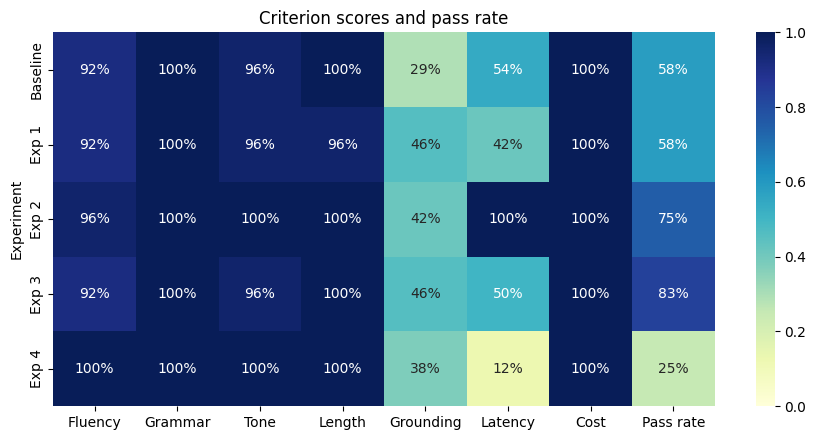

In [ ]:
if task4_criterion_score_df.empty:
    _ = mo.md("Task 4 criterion chart unavailable because no scored experiment rows were found.")
else:
    task4_plot_df = task4_criterion_score_df.set_index("Experiment")
    task4_plot_labels = task4_plot_df.map(
        lambda task4_plot_value: "—"
        if pd.isna(task4_plot_value)
        else f"{task4_plot_value:.0%}"
    )
    task4_plot_figure, task4_plot_axis = plt.subplots(figsize=(9, 4.5))
    sns.heatmap(
        task4_plot_df,
        annot=task4_plot_labels,
        fmt="",
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        ax=task4_plot_axis,
    )
    task4_plot_axis.set_title("Criterion scores and pass rate")
    task4_plot_figure.tight_layout()
    _ = mo.mpl.interactive(task4_plot_figure)
_

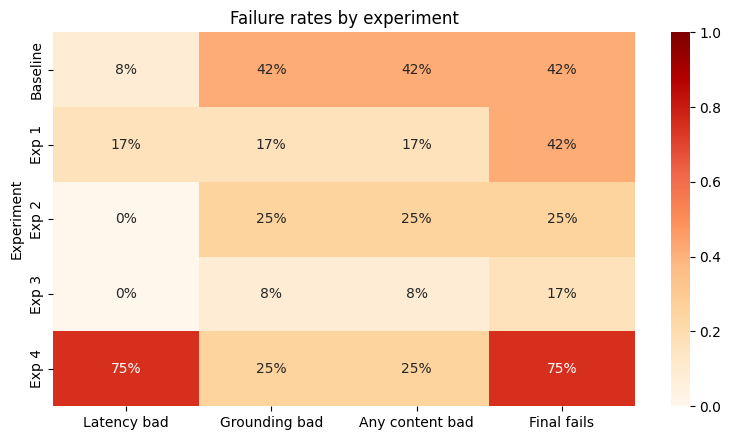

In [ ]:
task4_failure_rate_df = task4_failure_attribution_df.copy()
task4_failure_scored_counts = (
    task4_failure_rate_df["Scored sample"].str.split("/").str[0].astype(int)
)
task4_failure_columns = [
    "Latency bad",
    "Grounding bad",
    "Any content bad",
    "Final fails",
]
for task4_failure_column in task4_failure_columns:
    task4_failure_rate_df[task4_failure_column] = (
        task4_failure_rate_df[task4_failure_column] / task4_failure_scored_counts
    )

task4_failure_plot_df = task4_failure_rate_df.set_index("Experiment")[
    task4_failure_columns
]
task4_failure_plot_labels = task4_failure_plot_df.map(
    lambda task4_failure_value: "—"
    if pd.isna(task4_failure_value)
    else f"{task4_failure_value:.0%}"
)
task4_failure_figure, task4_failure_axis = plt.subplots(figsize=(8, 4.5))
sns.heatmap(
    task4_failure_plot_df,
    annot=task4_failure_plot_labels,
    fmt="",
    cmap="OrRd",
    vmin=0,
    vmax=1,
    ax=task4_failure_axis,
)
task4_failure_axis.set_title("Failure rates by experiment")
task4_failure_figure.tight_layout()
mo.mpl.interactive(task4_failure_figure)

## Task 4 analysis

- What changed in each experiment:
1. Exp 1 rewrote the prompt for a more natural voice and anti-list style because baseline outputs were often grounded enough to pass, but still sounded like spec lists in prose.
2. Exp 2 switched to Qwen3-30B while keeping the improved voice prompt to test whether a stronger model follows style and grounding instructions better.
3. Exp 3 added a hidden narrative scaffold to force a smoother rhetorical flow instead of one-sentence-per-feature writing.
4. Exp 4 used best-of-2 candidate selection to see whether reranking could improve polish without changing the prompt again.

- What is the best result?
1. **Experiment 3 is the best overall** - highest pass rate, low cost and low latency. Experiment 1 is the simpler prompt-only improvement - still good. Experiment 2 is fastest, and would be the best bar the grounding.
2. Experiment 4 reduced grounding failures the most on the manual sample, but the gain was not large enough to justify the extra pipeline overhead + it was not better than 1, 2, 3. I.e., it did not improve quality enough to justify the doubled cost.

# Task 5 — Judge Model

Flow:
- load the judge prompt,
- check whether the sanity-check CSV exists,
- if yes, analyze it,
- if not, run the judge on the first 5 rows.

In [ ]:
mo.md("## Task 5 prompt")
mo.md(TASK5_PROMPT_TEXT)

You are an expert product description evaluator. Your task is to rate a generated product description against an evaluation rubric.

You will receive:
1. The ORIGINAL PRODUCT DATA (name, attributes, material, warranty)
2. The GENERATED DESCRIPTION to evaluate

For each criterion below, you must:
- First write your reasoning (explanation)
- Then give a verdict: "good", "ok", or "bad"

## Evaluation Rubric

### Fluency - Natural, easy-to-read sentences
- good: Natural, easy-to-read flow; no awkward phrasing or unnatural constructions
- ok:   Mostly natural but 1-2 awkward phrases or choppy transitions
- bad:  Stilted, robotic, or hard to follow; multiple unnatural constructions

### Grammar - Correct spelling and punctuation
- good: Zero spelling or punctuation errors
- ok:   1-2 minor errors that don't impede understanding
- bad:  3+ errors, or any error that changes meaning or is immediately visible

### Tone - Matches friendly, credible sales voice
- good: Friendly, credible sales voice; persuasive without being pushy or hyperbolic
- ok:   Mostly appropriate but occasionally too formal, too casual, or generic
- bad:  Inappropriate tone: overly aggressive, robotic, or clearly mismatched to product

### Length - 50-90 words
- good: 50-90 words (inclusive)
- ok:   40-49 words or 91-110 words
- bad:  Fewer than 40 words or more than 110 words
Note: count the words in the description carefully before deciding.

### Grounding - Sticks to information provided (no hallucination)
- good: Every claim is traceable to the provided product name, attributes, material, or warranty; no invented features
- ok:   Minor embellishment that is reasonable for the product category but not explicitly in the data (for example, 'premium feel')
- bad:  Fabricated specs, invented features, or claims that contradict the provided data
Note: for grounding, compare the description against the ORIGINAL PRODUCT DATA carefully. Only accept claims that appear in the data.

## Important
- Evaluate only what is written; do not give credit for information that was provided but omitted from the description.
- For grounding, be strict: if a specific claim cannot be traced to the original product data, flag it.
- Your explanation must come BEFORE your verdict.

In [ ]:
task5_required_columns = [
    "product_name",
    "description",
    "judge_status",
    "judge_error",
]

task5_existing_df = None
if not NOTEBOOK_FORCE_RERUN:
    task5_existing_df = load_csv_artifact(
        TASK_05_JUDGE_SANITY_CSV_PATH,
        required_columns=task5_required_columns,
    )

if task5_existing_df is not None:
    task5_sanity_df = task5_existing_df.copy()
    TASK5_SOURCE = "Loaded packaged artifact: outputs/task_05_judge_sanity.csv"
else:
    if not NOTEBOOK_HAS_NEBIUS_KEY:
        raise RuntimeError(
            "Task 5 artifact is missing and NEBIUS_API_KEY is not set."
        )

    setup_mlflow("judge_runs")
    task5_run_judge = create_all_at_once_judge(
        model=NOTEBOOK_JUDGE_CONFIG.model,
        prompt=TASK5_PROMPT_TEXT,
        format_judge_input=format_judge_input,
        max_tokens=NOTEBOOK_JUDGE_ALL_MAX_TOKENS,
        timeout_seconds=NOTEBOOK_JUDGE_TIMEOUT_SECONDS,
    )
    task5_sample_df = task2_assignment_df.head(5)

    def _task5_judge_row(task5_sample_row: dict[str, object]) -> dict[str, object]:
        try:
            task5_result = task5_run_judge(
                task5_sample_row,
                str(task5_sample_row["generated_description"]),
            )
            task5_ratings = task5_result.to_ratings()
            return {
                "product_name": task5_sample_row["product_name"],
                "description": task5_sample_row["generated_description"],
                "judge_status": "ok",
                "judge_error": "",
                **{
                    f"{task5_rating_name}_verdict": task5_rating_value
                    for task5_rating_name, task5_rating_value in task5_ratings.items()
                },
                **{
                    f"{task5_rating_name}_explanation": getattr(
                        task5_result, task5_rating_name
                    ).explanation
                    for task5_rating_name in task5_ratings
                },
            }
        except Exception as task5_exc:
            return {
                "product_name": task5_sample_row["product_name"],
                "description": task5_sample_row["generated_description"],
                "judge_status": "error",
                "judge_error": str(task5_exc),
                **{f"{criterion_name}_verdict": "" for criterion_name in JUDGED_COLS},
                **{
                    f"{criterion_name}_explanation": ""
                    for criterion_name in JUDGED_COLS
                },
            }

    task5_rows = run_sync_batch(
        _task5_judge_row,
        task5_sample_df.to_dict("records"),
        max_concurrency=NOTEBOOK_JUDGE_SANITY_MAX_CONCURRENCY,
        desc="Task 5 sanity check",
    )
    task5_sanity_df = pd.DataFrame(task5_rows)
    TASK_05_JUDGE_SANITY_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    task5_sanity_df.to_csv(TASK_05_JUDGE_SANITY_CSV_PATH, index=False)
    TASK5_SOURCE = "Live sanity check ran and wrote: outputs/task_05_judge_sanity.csv"

mo.md(
    f"## Task 5 status\n\n- Source: {TASK5_SOURCE}\n- Judge model: `{NOTEBOOK_JUDGE_CONFIG.model}`"
)

## Task 5 status

- Source: Loaded packaged artifact: outputs/task_05_judge_sanity.csv
- Judge model: `nebius/Qwen/Qwen3-30B-A3B-Instruct-2507`

In [ ]:
mo.ui.table(task5_sanity_df, label="Task 5 sanity-check rows")

,_marimo_row_id,product_name,description,judge_status,judge_error,fluency_verdict,grammar_verdict,tone_verdict,length_verdict,grounding_verdict,fluency_explanation,grammar_explanation,tone_explanation,length_explanation,grounding_explanation
0,0,Apple iPhone 15 Pro,Experience the future of smartphones with the ...,ok,NaN,good,good,good,good,good,The description flows naturally with smooth tr...,The text contains no spelling or punctuation e...,"The tone is consistently friendly, professiona...","The description contains exactly 88 words, whi...",Every claim in the description is directly sup...
1,1,Samsung Galaxy S24 Ultra,Capture life's moments with unparalleled clari...,ok,NaN,good,good,good,good,good,The description flows naturally with smooth tr...,No spelling or punctuation errors are present....,"The tone is friendly, confident, and credible—...","The description contains exactly 88 words, whi...",Every claim in the description is directly sup...
2,2,Google Pixel 8 Pro,Capture life's moments with the Google Pixel 8...,ok,NaN,good,good,good,good,good,The description flows naturally with smooth tr...,The text contains no spelling or punctuation e...,"The tone is friendly, approachable, and credib...","The description contains exactly 88 words, whi...",Every claim in the description is directly sup...
3,3,Sony WH‑1000XM5 Headphones,Immerse yourself in pure sound with the Sony W...,ok,NaN,good,good,good,good,good,The description flows naturally with smooth tr...,There are no spelling or punctuation errors. A...,"The tone is friendly, credible, and persuasive...","The description contains exactly 88 words, whi...",Every claim in the description is directly sup...
4,4,Bose QuietComfort Ultra Earbuds,Immerse yourself in pure sound with the Bose Q...,ok,NaN,good,good,good,good,good,The description flows naturally with smooth tr...,There are no spelling or punctuation errors. A...,"The tone is friendly, credible, and persuasive...","The description contains exactly 88 words, whi...",Every claim in the description is directly sup...


In [ ]:
mo.md(
    f"""
    ## Task 5 write-up notes

    - Judge model used here: `{NOTEBOOK_JUDGE_CONFIG.model}`
    - Current notebook default: `Qwen/Qwen3-30B-A3B-Instruct-2507` to reduce the risk of slow or brittle structured-output judging on Gemma.
    - Gemma had proven problematic as a judge due to low schema adherence: https://i.imgur.com/4oeuFYQ.png
    - **Why explanation first:** LLMs generate tokens left-to-right. If 'verdict' came first, the model would build the rest of the answer around that score, somewhat like a priming or anchoring bias. Putting 'explanation' first forces the model to reason before outputting the verdict.
    """
)

## Task 5 write-up notes

- Judge model used here: `nebius/Qwen/Qwen3-30B-A3B-Instruct-2507`
- Current notebook default: `Qwen/Qwen3-30B-A3B-Instruct-2507` to reduce the risk of slow or brittle structured-output judging on Gemma.
- Gemma had proven problematic as a judge due to low schema adherence: https://i.imgur.com/4oeuFYQ.png
- **Why explanation first:** LLMs generate tokens left-to-right. If 'verdict' came first, the model would build the rest of the answer around that score, somewhat like a priming or anchoring bias. Putting 'explanation' first forces the model to reason before outputting the verdict.

# Task 6 — Run and Analyze the Judge

Flow:
- define the all-at-once and per-criterion judge prompts,
- check whether the full Task 6 CSV exists,
- if yes, analyze it,
- if not, run the full judge pipeline and then analyze it.

In [ ]:
mo.md("## Task 6 per-criterion prompt template")
mo.md(TASK6_SINGLE_PROMPT_TEMPLATE)

You are an expert product description evaluator. Your task is to rate a generated product description on ONE specific criterion.

You will receive:
1. The ORIGINAL PRODUCT DATA (name, attributes, material, warranty)
2. The GENERATED DESCRIPTION to evaluate
3. The criterion to evaluate and its rubric

## Criterion to Evaluate
**{criterion_name}** - {criterion_description}

### Rubric
- good: {good}
- ok:   {ok}
- bad:  {bad}

## Instructions
- Focus exclusively on this criterion. Do not consider other aspects of the description.
- First write your reasoning (explanation), then give your verdict: "good", "ok", or "bad".
- Your explanation must come BEFORE your verdict.
{extra_instructions}

In [ ]:
task6_required_columns = [
    "experiment_label",
    "generated_description",
    "judge_status",
    "judge_final_score",
    "single_judge_status",
    "single_final_score",
    *[f"judge_{task6_required_name}" for task6_required_name in JUDGED_COLS],
    *[f"single_{task6_required_name}" for task6_required_name in JUDGED_COLS],
]

task6_existing_df = None
if not NOTEBOOK_FORCE_RERUN:
    task6_existing_df = load_csv_artifact(
        TASK_06_JUDGED_EXPERIMENTS_CSV_PATH,
        required_columns=task6_required_columns,
    )

if task6_existing_df is not None:
    task6_results_df = apply_programmatic_scores(task6_existing_df.copy())
    TASK6_SOURCE = "Loaded packaged artifact: outputs/task_06_judged_experiments.csv"
else:
    if not NOTEBOOK_HAS_NEBIUS_KEY:
        raise RuntimeError(
            "Task 6 artifact is missing and NEBIUS_API_KEY is not set."
        )

    setup_mlflow("judge_runs")
    task6_run_judge = create_all_at_once_judge(
        model=NOTEBOOK_JUDGE_CONFIG.model,
        prompt=TASK5_PROMPT_TEXT,
        format_judge_input=format_judge_input,
        max_tokens=NOTEBOOK_JUDGE_ALL_MAX_TOKENS,
        timeout_seconds=NOTEBOOK_JUDGE_TIMEOUT_SECONDS,
    )
    task6_single_judges = create_single_judges(
        model=NOTEBOOK_JUDGE_CONFIG.model,
        prompt_template=TASK6_SINGLE_PROMPT_TEMPLATE,
        judged_criteria=JUDGED_CRITERIA,
        format_judge_input=format_judge_input,
        max_tokens=NOTEBOOK_JUDGE_SINGLE_MAX_TOKENS,
        timeout_seconds=NOTEBOOK_JUDGE_TIMEOUT_SECONDS,
    )
    task6_input_rows = task4_experiments_df.to_dict("records")

    def task6_combined_final_score(task6_score_row: dict[str, object], task6_ratings: dict[str, str]) -> str:
        task6_full_ratings = {
            task6_full_name: task6_ratings.get(task6_full_name, "")
            for task6_full_name in JUDGED_COLS
        }
        task6_full_ratings["latency"] = str(task6_score_row.get("latency", "")).strip().lower()
        task6_full_ratings["cost"] = str(task6_score_row.get("cost", "")).strip().lower()
        return compute_final_score(task6_full_ratings)

    def task6_all_at_once_row(task6_row_data: dict[str, object]) -> dict[str, object]:
        try:
            task6_all_result = task6_run_judge(
                task6_row_data,
                str(task6_row_data["generated_description"]),
            )
            task6_all_ratings = task6_all_result.to_ratings()
            return {
                **{
                    f"judge_{task6_all_name}": task6_all_value
                    for task6_all_name, task6_all_value in task6_all_ratings.items()
                },
                **{
                    f"judge_{task6_all_name}_explanation": getattr(
                        task6_all_result, task6_all_name
                    ).explanation
                    for task6_all_name in task6_all_ratings
                },
                "judge_final_score": task6_combined_final_score(
                    task6_row_data,
                    task6_all_ratings,
                ),
                "judge_status": "ok",
                "judge_error": "",
            }
        except Exception as task6_all_exc:
            return {
                **{
                    f"judge_{task6_blank_name}": ""
                    for task6_blank_name in JUDGED_COLS
                },
                **{
                    f"judge_{task6_blank_name}_explanation": ""
                    for task6_blank_name in JUDGED_COLS
                },
                "judge_final_score": "",
                "judge_status": "error",
                "judge_error": str(task6_all_exc),
            }

    with mlflow.start_run(run_name="task6_judge_all_criteria"):
        mlflow.log_params(
            {
                "judge_model": NOTEBOOK_JUDGE_CONFIG.model_id,
                "mode": "all_criteria_at_once",
                "temperature": 0.0,
                "total_calls": len(task6_input_rows),
                "max_concurrency": NOTEBOOK_JUDGE_MAX_CONCURRENCY,
            }
        )
        task6_all_rows = run_sync_batch(
            task6_all_at_once_row,
            task6_input_rows,
            max_concurrency=NOTEBOOK_JUDGE_MAX_CONCURRENCY,
            desc="Task 6 all-at-once judge",
        )
        task6_all_df = pd.DataFrame(task6_all_rows)
        task6_all_ok_mask = task6_all_df["judge_status"] == "ok"
        mlflow.log_metrics(
            {
                "pass_rate": (
                    (
                        task6_all_df.loc[task6_all_ok_mask, "judge_final_score"]
                        == "pass"
                    ).mean()
                    if task6_all_ok_mask.any()
                    else 0.0
                ),
                "error_rate": (task6_all_df["judge_status"] == "error").mean(),
            }
        )

    task6_results_df = task4_experiments_df.copy()
    for task6_all_column in task6_all_df.columns:
        task6_results_df[task6_all_column] = task6_all_df[task6_all_column].values

    def task6_single_row(task6_row_data: dict[str, object]) -> dict[str, object]:
        task6_single_output = {}
        task6_single_errors = []
        for task6_single_criterion in JUDGED_CRITERIA:
            task6_single_name = task6_single_criterion.name.lower()
            try:
                task6_single_result = task6_single_judges[task6_single_name](
                    task6_row_data,
                    str(task6_row_data["generated_description"]),
                )
                task6_single_output[f"single_{task6_single_name}"] = (
                    task6_single_result.verdict.value
                )
                task6_single_output[
                    f"single_{task6_single_name}_explanation"
                ] = task6_single_result.explanation
                task6_single_output[f"single_{task6_single_name}_status"] = "ok"
                task6_single_output[f"single_{task6_single_name}_error"] = ""
            except Exception as task6_single_exc:
                task6_single_output[f"single_{task6_single_name}"] = ""
                task6_single_output[
                    f"single_{task6_single_name}_explanation"
                ] = ""
                task6_single_output[f"single_{task6_single_name}_status"] = "error"
                task6_single_output[f"single_{task6_single_name}_error"] = str(
                    task6_single_exc
                )
                task6_single_errors.append(
                    f"{task6_single_name}: {task6_single_exc}"
                )
        task6_single_output["single_judge_status"] = (
            "ok"
            if not task6_single_errors
            else (
                "partial_error"
                if len(task6_single_errors) < len(JUDGED_CRITERIA)
                else "error"
            )
        )
        task6_single_output["single_judge_error"] = "; ".join(
            task6_single_errors
        )
        return task6_single_output

    with mlflow.start_run(run_name="task6_judge_per_criterion"):
        mlflow.log_params(
            {
                "judge_model": NOTEBOOK_JUDGE_CONFIG.model_id,
                "mode": "per_criterion_separate_calls",
                "temperature": 0.0,
                "total_calls": len(task6_input_rows) * len(JUDGED_COLS),
                "max_concurrency": NOTEBOOK_JUDGE_MAX_CONCURRENCY,
            }
        )
        task6_single_df = pd.DataFrame(
            run_sync_batch(
                task6_single_row,
                task6_input_rows,
                max_concurrency=NOTEBOOK_JUDGE_MAX_CONCURRENCY,
                desc="Task 6 per-criterion judge",
            )
        )
        task6_single_df["single_final_score"] = task6_single_df.apply(
            lambda task6_single_score_row: task6_combined_final_score(
                task6_results_df.loc[task6_single_score_row.name].to_dict(),
                {
                    task6_single_final_name.name.lower(): str(
                        task6_single_score_row.get(
                            f"single_{task6_single_final_name.name.lower()}",
                            "",
                        )
                    )
                    .strip()
                    .lower()
                    for task6_single_final_name in JUDGED_CRITERIA
                },
            ),
            axis=1,
        )
        task6_single_ok_mask = (
            task6_single_df["single_judge_status"] == "ok"
        )
        mlflow.log_metrics(
            {
                "pass_rate": (
                    (
                        task6_single_df.loc[
                            task6_single_ok_mask,
                            "single_final_score",
                        ]
                        == "pass"
                    ).mean()
                    if task6_single_ok_mask.any()
                    else 0.0
                ),
                "error_rate": (
                    task6_single_df["single_judge_status"] != "ok"
                ).mean(),
            }
        )

    for task6_single_column in task6_single_df.columns:
        task6_results_df[task6_single_column] = task6_single_df[
            task6_single_column
        ].values

    TASK_06_JUDGED_EXPERIMENTS_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    task6_results_df.to_csv(TASK_06_JUDGED_EXPERIMENTS_CSV_PATH, index=False)
    TASK6_SOURCE = "Live judge pipeline ran and wrote: outputs/task_06_judged_experiments.csv"

In [ ]:
mo.md(
    f"""
    ## Task 6 status

    - Source: {TASK6_SOURCE}
    - Judge model: `{NOTEBOOK_JUDGE_CONFIG.model}`
    - Judge max concurrency: `{NOTEBOOK_JUDGE_MAX_CONCURRENCY}`
    """
)

## Task 6 status

- Source: Loaded packaged artifact: outputs/task_06_judged_experiments.csv
- Judge model: `nebius/Qwen/Qwen3-30B-A3B-Instruct-2507`
- Judge max concurrency: `6`

In [ ]:
task6_human_scored_df = task6_results_df[
    task6_results_df["fluency"].fillna("").astype(str).str.strip() != ""
].copy()

if task6_human_scored_df.empty:
    task6_agreement_df = pd.DataFrame()
    _ = mo.md("No manual Task 4 labels were found, so agreement cannot be computed.")
else:
    task6_agreement_rows = []
    for task6_agreement_name in JUDGED_COLS:
        task6_all_col = f"judge_{task6_agreement_name}"
        task6_single_col = f"single_{task6_agreement_name}"
        task6_single_status_col = f"single_{task6_agreement_name}_status"
        task6_comparable_df = task6_human_scored_df[
            (task6_human_scored_df["judge_status"] == "ok")
            & (task6_human_scored_df[task6_single_status_col] == "ok")
            & (task6_human_scored_df[task6_all_col] != "")
            & (task6_human_scored_df[task6_single_col] != "")
        ].copy()
        if task6_comparable_df.empty:
            continue
        task6_all_agreement = (
            task6_comparable_df[task6_agreement_name].str.strip()
            == task6_comparable_df[task6_all_col].str.strip()
        ).mean()
        task6_single_agreement = (
            task6_comparable_df[task6_agreement_name].str.strip()
            == task6_comparable_df[task6_single_col].str.strip()
        ).mean()
        task6_agreement_rows.append(
            {
                "Criterion": task6_agreement_name.capitalize(),
                "N compared": len(task6_comparable_df),
                "All-at-Once %": f"{task6_all_agreement:.0%}",
                "Per-Criterion %": f"{task6_single_agreement:.0%}",
                "Delta": f"{(task6_single_agreement - task6_all_agreement):+.0%}",
                "All-at-Once (raw)": task6_all_agreement,
                "Per-Criterion (raw)": task6_single_agreement,
            }
        )
    task6_agreement_df = pd.DataFrame(task6_agreement_rows)
    if task6_agreement_df.empty:
        _ = mo.md("Manual labels exist, but no rows have both judge outputs.")
    else:
        task6_agreement_df = task6_agreement_df.sort_values(
            "Per-Criterion (raw)", ascending=False
        )
        _ = mo.ui.table(
            task6_agreement_df.drop(
                columns=["All-at-Once (raw)", "Per-Criterion (raw)"]
            ),
            label="Human agreement: all-at-once vs per-criterion",
        )
_

,_marimo_row_id,Criterion,N compared,All-at-Once %,Per-Criterion %,Delta
1,0,Grammar,60,100%,98%,-2%
2,1,Tone,60,95%,93%,-2%
0,2,Fluency,60,88%,88%,+0%
3,3,Length,60,98%,58%,-40%
4,4,Grounding,60,7%,7%,+0%


In [ ]:
task6_experiment_summary_rows = []
for task6_experiment_name, task6_experiment_group in task6_results_df.groupby(
    "experiment_label",
    sort=False,
):
    task6_labeled_group = task6_human_scored_df[
        task6_human_scored_df["experiment_label"] == task6_experiment_name
    ].copy()
    task6_all_ok = task6_experiment_group["judge_status"].eq("ok")
    task6_single_ok = task6_experiment_group["single_judge_status"].eq("ok")
    task6_experiment_summary_rows.append(
        {
            "Experiment": task6_experiment_name,
            "Rows": len(task6_experiment_group),
            "Human-labeled rows": len(task6_labeled_group),
            "All-at-Once pass %": (
                f"{(task6_experiment_group.loc[task6_all_ok, 'judge_final_score'] == 'pass').mean():.0%}"
                if task6_all_ok.any()
                else "—"
            ),
            "Per-Criterion pass %": (
                f"{(task6_experiment_group.loc[task6_single_ok, 'single_final_score'] == 'pass').mean():.0%}"
                if task6_single_ok.any()
                else "—"
            ),
            "Human pass %": (
                f"{task6_labeled_group['final_score'].eq('pass').mean():.0%}"
                if len(task6_labeled_group)
                else "—"
            ),
        }
    )
task6_experiment_summary_df = pd.DataFrame(task6_experiment_summary_rows)

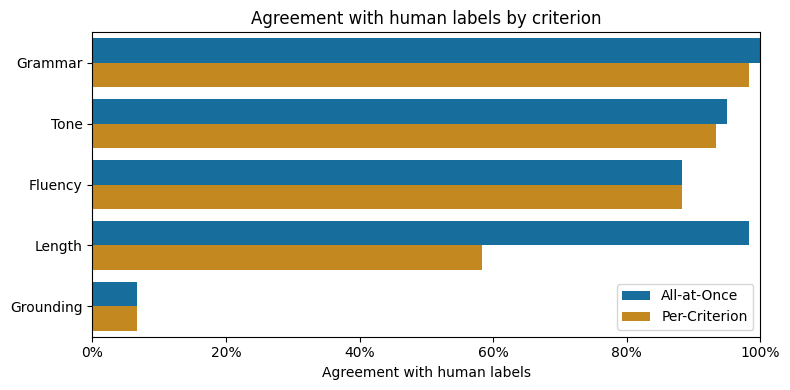

In [ ]:
if task6_agreement_df.empty:
    _ = mo.md("Agreement chart unavailable until both human labels and judge outputs are present.")
else:
    task6_agreement_plot_df = task6_agreement_df[
        ["Criterion", "All-at-Once (raw)", "Per-Criterion (raw)"]
    ].melt(
        id_vars="Criterion",
        var_name="Judge mode",
        value_name="Agreement",
    )
    task6_agreement_plot_df["Judge mode"] = task6_agreement_plot_df[
        "Judge mode"
    ].replace(
        {
            "All-at-Once (raw)": "All-at-Once",
            "Per-Criterion (raw)": "Per-Criterion",
        }
    )
    task6_agreement_figure, task6_agreement_axis = plt.subplots(
        figsize=(8, 4)
    )
    sns.barplot(
        data=task6_agreement_plot_df,
        x="Agreement",
        y="Criterion",
        hue="Judge mode",
        ax=task6_agreement_axis,
        palette="colorblind",
    )
    task6_agreement_axis.set_xlim(0, 1)
    task6_agreement_axis.xaxis.set_major_formatter(
        mtick.PercentFormatter(xmax=1.0)
    )
    task6_agreement_axis.set_xlabel("Agreement with human labels")
    task6_agreement_axis.set_ylabel("")
    task6_agreement_axis.set_title("Agreement with human labels by criterion")
    task6_agreement_axis.legend(title="")
    task6_agreement_figure.tight_layout()
    _ = mo.mpl.interactive(task6_agreement_figure)
_

In [ ]:
mo.ui.table(
    task6_experiment_summary_df,
    label="Human vs judge pass rates by Task 4 experiment",
)

,_marimo_row_id,Experiment,Rows,Human-labeled rows,All-at-Once pass %,Per-Criterion pass %,Human pass %
0,0,Baseline,50,12,94%,94%,58%
1,1,Exp 1,50,12,96%,94%,58%
2,2,Exp 2,50,12,96%,98%,75%
3,3,Exp 3,50,12,100%,98%,83%
4,4,Exp 4,50,12,26%,26%,25%


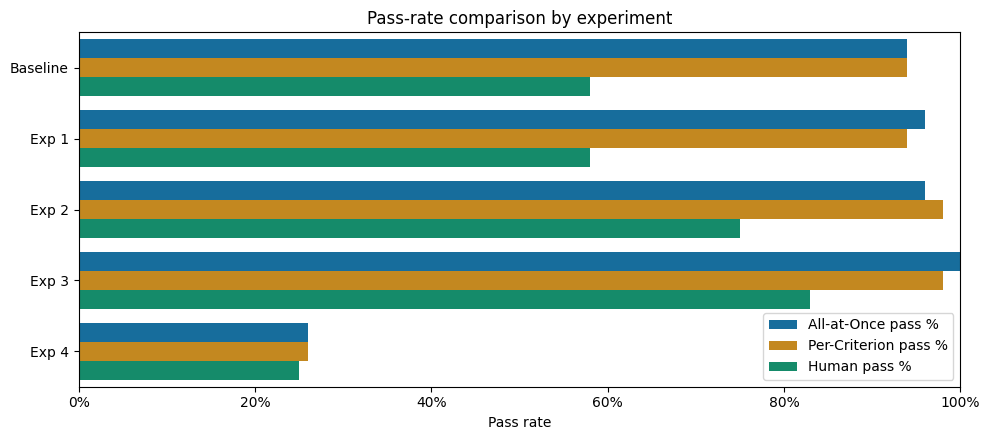

In [ ]:
task6_pass_rate_plot_df = task6_experiment_summary_df[
    [
        "Experiment",
        "All-at-Once pass %",
        "Per-Criterion pass %",
        "Human pass %",
    ]
].melt(
    id_vars="Experiment",
    var_name="Pass-rate source",
    value_name="Pass rate label",
)
task6_pass_rate_plot_df["Pass rate"] = pd.to_numeric(
    task6_pass_rate_plot_df["Pass rate label"].str.rstrip("%"),
    errors="coerce",
) / 100
task6_pass_rate_plot_df = task6_pass_rate_plot_df.dropna(
    subset=["Pass rate"]
)
if task6_pass_rate_plot_df.empty:
    _ = mo.md("Pass-rate chart unavailable until Task 6 outputs and human labels are present.")
else:
    task6_pass_rate_figure, task6_pass_rate_axis = plt.subplots(
        figsize=(10, 4.5)
    )
    sns.barplot(
        data=task6_pass_rate_plot_df,
        x="Pass rate",
        y="Experiment",
        hue="Pass-rate source",
        ax=task6_pass_rate_axis,
        palette="colorblind",
    )
    task6_pass_rate_axis.set_xlim(0, 1)
    task6_pass_rate_axis.xaxis.set_major_formatter(
        mtick.PercentFormatter(xmax=1.0)
    )
    task6_pass_rate_axis.set_xlabel("Pass rate")
    task6_pass_rate_axis.set_ylabel("")
    task6_pass_rate_axis.set_title("Pass-rate comparison by experiment")
    task6_pass_rate_axis.legend(title="")
    task6_pass_rate_figure.tight_layout()
    _ = mo.mpl.interactive(task6_pass_rate_figure)

_

## Agreement analysis

- Where the human and judge agree: **agreement is strongest on grammar and tone**, and still high on fluency.
- Where they diverge: **grounding** is the clear failure mode for automated judging in this repo, and length is only moderate even though it improves greatly in the all-at-once mode.
- **Why per-criterion judging changes results:** decomposing the task helps somewhat for length, but it does not solve grounding. I'd also argue that it does the same as explanation-verdict bias in multiple dimensions: per-criterion doesn't prime the LLM to score other rubrics based on current explanations.
- The judge also stays **more lenient** than the human on Baseline, Exp 1, Exp 2, and Exp 3.

## Final recommendation

**LLMaaJ clearly wins** on:
- cost,
- scale,
- consistency
Once the rubric and prompt are fixed, it can score the full experiment table much faster than a human review pass. The agreement table shows that this works well for style-oriented criteria such as grammar, tone, and fluency. I'd say that 'fuzzy' LLM-bound tasks are simpler for it, while 'deterministic' ones are increasingly harder.

**The trade-off** is accuracy on harder criteria.
Length agreement is only moderate.
Grounding is a total fiasco: agreement is near zero in both judge modes. Possible reason: me being extremely strict and "they shouldn't be THAT good, those are 9B models".

**Recommended production approach:** use a hybrid workflow.
Keep human scoring for rubric design and periodic calibration + human in the loop emergency checks, then use LLM-as-a-judge for large-scale routine monitoring. I would NOT rely (yet!) on LLMs for grounding-sensitive decisions, also critical domains, e.g. finance, legal, healthcare, military, insurance, etc.

## Deliverables in this bundle

- `.env.example`
- `assignment_colab.py`
- `assignment_colab.ipynb`
- `assignment_colab.html`
- `data/products.csv`
- `outputs/assignment_01.xlsx`
- `outputs/task_04_experiments.xlsx`
- `outputs/task_05_judge_sanity.csv`
- `outputs/task_06_judged_experiments.csv`
- `outputs/reports/task_04_experiments/*.csv`